# Home Credit Default Risk Prediction
## Virtual Internship Experience — Rakamin Academy × Home Credit

---

### Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Load Dataset & Column Descriptions |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Preprocessing & Feature Engineering |
| 4 | Model Training |
| 5 | Model Evaluation |
| 6 | Business Recommendations |

---

### Objective

Home Credit wants to broaden financial inclusion by lending to customers who are underserved by traditional credit scoring. The goal is to predict **whether a loan applicant will have difficulty repaying** (`TARGET = 1`) so that loans can be offered with appropriate terms — rather than rejected outright.

**Target variable:** `TARGET` — binary (1 = payment difficulty, 0 = repaid successfully)  
**Primary metric:** ROC-AUC  
**Models required:** Logistic Regression + at least one other

## Background & Problem Research
> *Task step 2: Pelajari konteks masalah dari sumber eksternal*

### Business Context
Home Credit serves customers who are **unbanked or underbanked** — people with little or no formal credit history who are typically rejected by traditional banks. To serve this market, Home Credit uses alternative data (telco records, transaction history, demographic information) to assess creditworthiness.

The core tension is:
- **Too strict** → creditworthy customers are rejected → loss of revenue and financial exclusion
- **Too loose** → high-risk customers are approved → loan defaults → financial loss

### Problem Statement
Build a model that predicts the probability that an applicant will have **payment difficulty** so that:
1. Creditworthy customers are not wrongly rejected
2. Loan terms (principal, maturity, repayment schedule) can be tailored to the applicant's actual repayment capacity

### Goal, Objective & Metrics

| | |
|---|---|
| **Goal** | Maximise loan approval rates while minimising default losses |
| **Objective** | Predict `TARGET = 1` (payment difficulty) with high recall to catch defaulters |
| **Primary Metric** | **ROC-AUC** — measures ranking ability across all thresholds, robust to class imbalance |
| **Secondary Metrics** | Recall (Bad), Precision (Bad), F1 (Bad) — capture real-world classification performance |
| **Business Metric** | Net Benefit (IDR) — losses prevented minus revenue lost from false positives |

### Dataset Overview

| Table | Rows (approx) | Key Info |
|---|---|---|
| `application_train/test.csv` | 307,511 / 48,744 | Main table — applicant demographics, loan amounts, EXT_SOURCE scores |
| `bureau.csv` | 1.7M | Credits at other institutions reported to Credit Bureau |
| `bureau_balance.csv` | 27M | Monthly DPD status for bureau credits |
| `previous_application.csv` | 1.7M | Past loan applications at Home Credit |
| `POS_CASH_balance.csv` | 10M | Monthly balances of previous POS/cash loans |
| `credit_card_balance.csv` | 3.8M | Monthly credit card behaviour at Home Credit |
| `installments_payments.csv` | 13.6M | Actual repayment history — paid vs due |

All supplementary tables link to the main table via `SK_ID_CURR`. The key challenge is aggregating multi-row history tables into single-row applicant-level features.

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection        import permutation_importance
from sklearn.metrics           import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED           = 42
TEST_SIZE      = 0.20
MISSING_THRESH = 0.60
np.random.seed(SEED)

print('Libraries imported successfully!')


Libraries imported successfully!


## Step 1 — Load Dataset & Column Descriptions
> Load the main application table and the column description file to understand every feature before touching the data.

In [2]:
app_train    = pd.read_csv('application_train.csv')
app_test     = pd.read_csv('application_test.csv')
bureau       = pd.read_csv('bureau.csv')
bureau_bal   = pd.read_csv('bureau_balance.csv')
prev_app     = pd.read_csv('previous_application.csv')
pos_cash     = pd.read_csv('POS_CASH_balance.csv')
credit_card  = pd.read_csv('credit_card_balance.csv')
installments = pd.read_csv('installments_payments.csv')
col_desc     = pd.read_csv('HomeCredit_columns_description.csv', encoding='latin-1')
submission   = pd.read_csv('sample_submission.csv')

print(f'Train            : {app_train.shape[0]:,} rows x {app_train.shape[1]} cols')
print(f'Test             : {app_test.shape[0]:,} rows x {app_test.shape[1]} cols')
print(f'Memory (train)   : {app_train.memory_usage(deep=True).sum()/1024**2:.1f} MB')

app_train.head(3)

Train            : 307,511 rows x 122 cols
Test             : 48,744 rows x 121 cols
Memory (train)   : 505.0 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,...,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,...,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,...,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [3]:
# Column lookup helper — uses HomeCredit_columns_description.csv
col_desc = col_desc.rename(columns={'Row':'column','Table':'table',
                                     'Description':'description','Special':'special'})

def describe_col(pattern):
    """Show description(s) for any column matching `pattern`."""
    mask = col_desc['column'].str.contains(pattern, case=False, na=False)
    return col_desc.loc[mask, ['table','column','description']].reset_index(drop=True)

print('=== Data Types ===')
app_train.dtypes.value_counts()

=== Data Types ===


float64    65
int64      41
object     16
Name: count, dtype: int64

In [4]:
# Duplicate & structure check
print('One row = one loan application')
print(f'Total rows           : {len(app_train):,}')
print(f'Unique SK_ID_CURR    : {app_train["SK_ID_CURR"].nunique():,}')
print(f'Duplicate rows       : {app_train.duplicated().sum():,}')

One row = one loan application
Total rows           : 307,511
Unique SK_ID_CURR    : 307,511
Duplicate rows       : 0


## Step 2 — Exploratory Data Analysis (EDA)
> Understand the data, identify patterns, and find features that drive default risk.

### 2.1 Missing Value Analysis
> Decide which columns to drop and which to impute.

Columns with any missing  : 67
Columns with >60% missing : 17


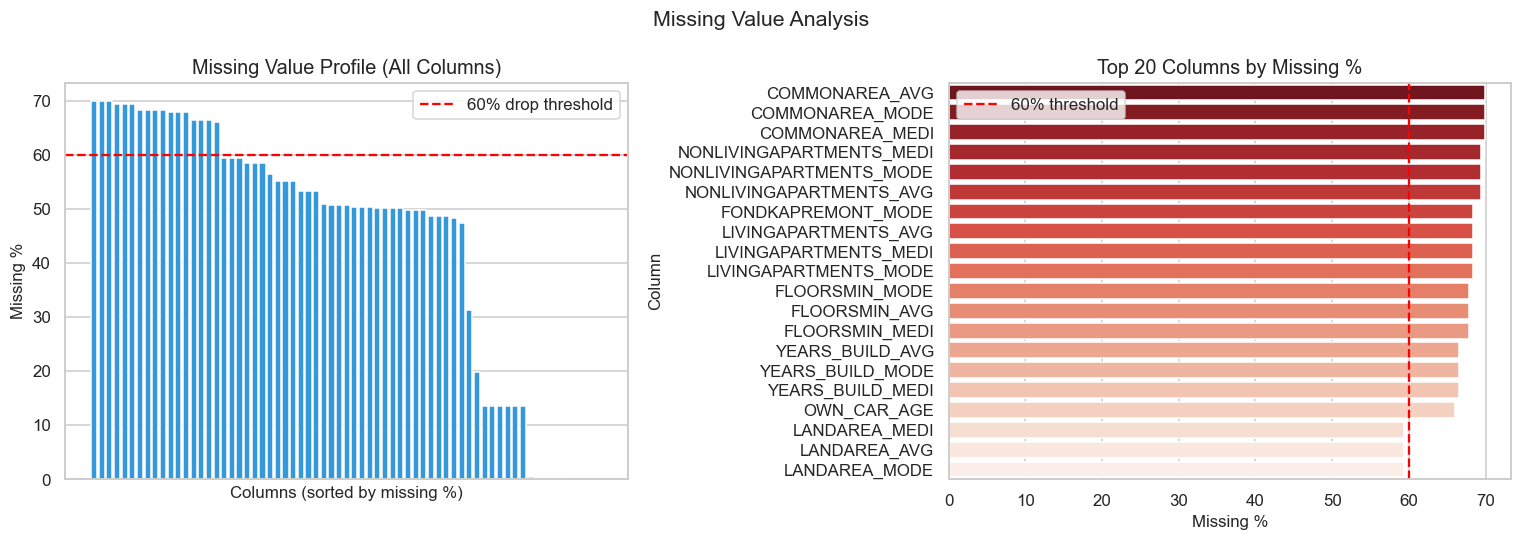

In [5]:
missing = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_nz = missing[missing > 0]

print(f'Columns with any missing  : {len(missing_nz)}')
print(f'Columns with >60% missing : {(missing_nz > 60).sum()}')

top20_missing = missing_nz.head(20).reset_index()
top20_missing.columns = ['Column', 'Missing %']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All columns profile
axes[0].bar(range(len(missing_nz)), missing_nz.values, color='#3498db')
axes[0].axhline(60, color='red', linestyle='--', label='60% drop threshold')
axes[0].set_xticks([])
axes[0].set_xlabel('Columns (sorted by missing %)')
axes[0].set_ylabel('Missing %')
axes[0].set_title('Missing Value Profile (All Columns)')
axes[0].legend()

# Top 20
sns.barplot(data=top20_missing, y='Column', x='Missing %', ax=axes[1], palette='Reds_r')
axes[1].axvline(60, color='red', linestyle='--', label='60% threshold')
axes[1].set_title('Top 20 Columns by Missing %')
axes[1].legend()

plt.suptitle('Missing Value Analysis', fontsize=14)
plt.tight_layout()
plt.show()

### Observation — Missing Values
- **67 out of 122 columns** in the application table have at least one missing value.
- **17 columns exceed 60% missing** — these are dropped entirely as they carry too little information to impute reliably. Most are building-related features (`COMMONAREA_AVG`, `FONDKAPREMONT_MODE`, etc.) that are simply not recorded for many applicants.
- Remaining numeric missing values are imputed with the **column median**, which is robust to the right-skewed distributions common in financial data (income, credit amounts).
- Categorical missing values are filled with `'Unknown'` before label encoding.

### 2.2 Target Variable
> Understand the class distribution before modelling.

  0 (No Difficulty):  282,686  (91.93%)
  1 (Payment Difficulty):   24,825  (8.07%)


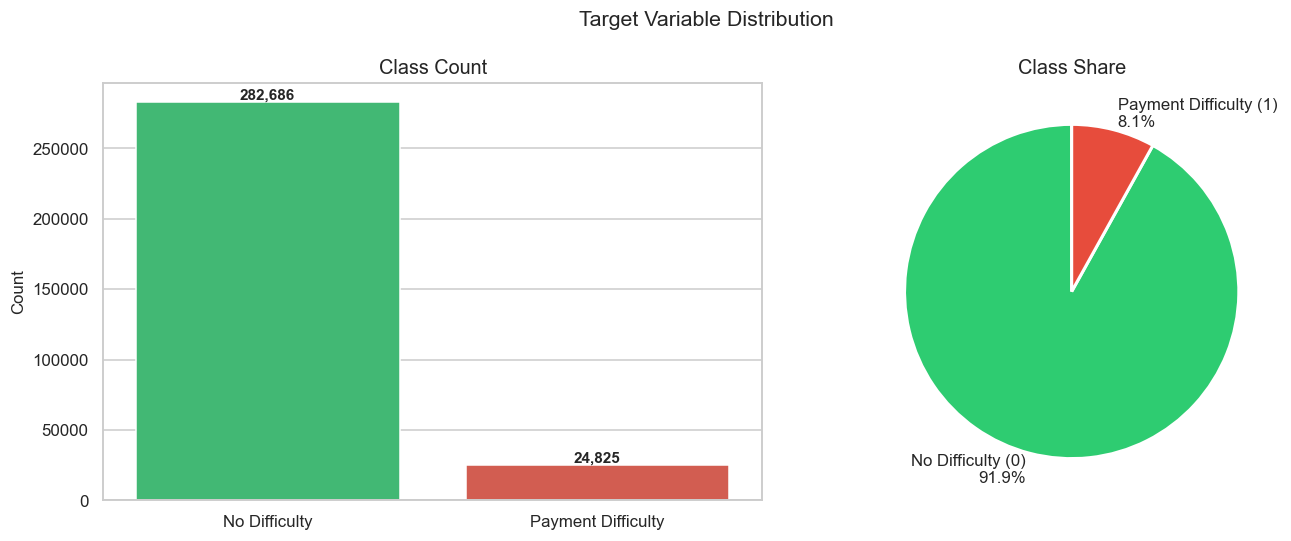

In [6]:
target_vc  = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True).mul(100)

for lbl in target_vc.index:
    tag = 'No Difficulty' if lbl == 0 else 'Payment Difficulty'
    print(f'  {lbl} ({tag}): {target_vc[lbl]:>8,}  ({target_pct[lbl]:.2f}%)')

target_df = target_vc.reset_index()
target_df.columns = ['TARGET', 'Count']
target_df['Label'] = target_df['TARGET'].map({0:'No Difficulty', 1:'Payment Difficulty'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=target_df, x='Label', y='Count',
            palette={'No Difficulty':'#2ecc71','Payment Difficulty':'#e74c3c'},
            ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Count')
axes[0].set_xlabel('')

axes[1].pie(target_vc.values,
            labels=[f'No Difficulty (0)\n{target_pct[0]:.1f}%',
                    f'Payment Difficulty (1)\n{target_pct[1]:.1f}%'],
            colors=['#2ecc71','#e74c3c'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Share')

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Observation — Target Variable
- **282,686 applicants (91.93%)** had no payment difficulty — **24,825 (8.07%)** did.
- This is a **significant class imbalance** — a naive model that predicts 'no difficulty' for everyone would achieve 91.93% accuracy while being completely useless for the actual task.
- All models use `class_weight='balanced'` to compensate, which re-weights the loss function to treat each default case as ~11x more important.
- **ROC-AUC** is the primary metric because it measures ranking ability across all thresholds, independent of the imbalance.

### 2.3 Numerical Feature Distributions
> Check the spread and shape of key numeric features.

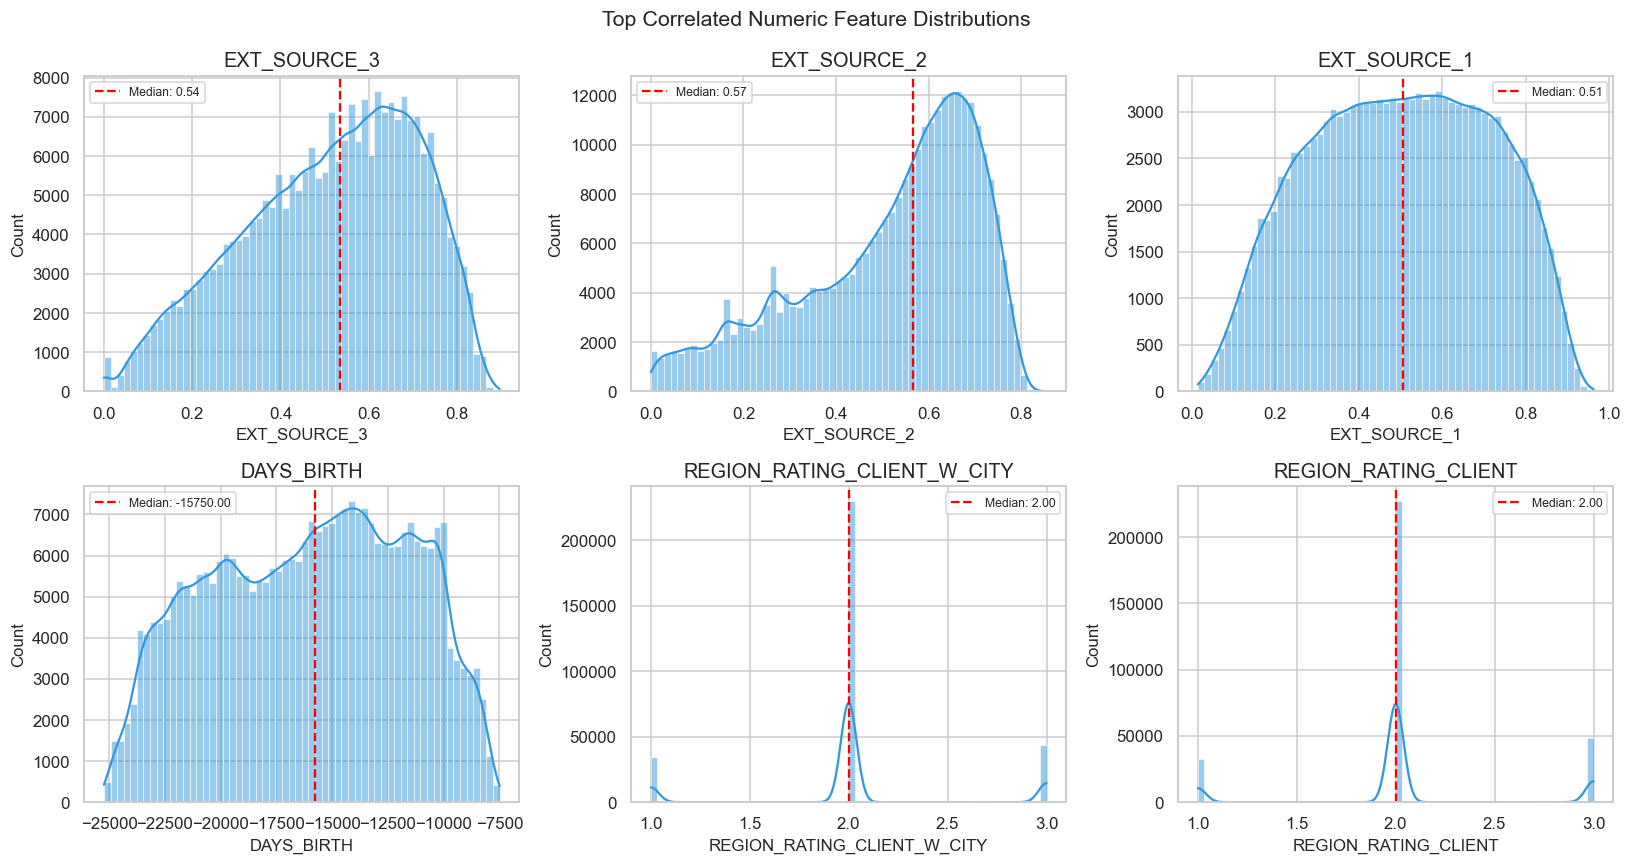

In [7]:
# Pick top numeric columns most correlated with TARGET
num_top = (
    app_train.select_dtypes(include=np.number)
    .corr()['TARGET'].drop('TARGET').abs()
    .sort_values(ascending=False).head(6).index.tolist()
)
log_cols = {'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), num_top):
    data = np.log1p(app_train[col].dropna()) if col in log_cols else app_train[col].dropna()
    sns.histplot(data, bins=60, ax=ax, color='#3498db', kde=True)
    ax.axvline(data.median(), color='red', linestyle='--',
               label=f'Median: {data.median():.2f}')
    ax.set_title(f'log({col})' if col in log_cols else col)
    ax.legend(fontsize=8)

plt.suptitle('Top Correlated Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Feature vs Target (Bivariate Analysis)
> Compare key features between no-difficulty and payment-difficulty applicants.

#### Observation — Numerical Distributions
- **EXT_SOURCE scores** are right-skewed with a meaningful mass near 0 — many applicants have low scores, which aligns with the target population being underserved by traditional credit.
- **DAYS_BIRTH (age)** shows a relatively uniform distribution — default risk is not concentrated in one age band but in the younger end.
- **AMT_INCOME_TOTAL and AMT_CREDIT** are highly right-skewed (log scale used) — a few applicants have very high incomes/loans. The bulk of applicants cluster in lower income ranges.
- Median lines confirm that payment-difficulty applicants tend to have **lower EXT_SOURCE scores and younger age** than non-default applicants.

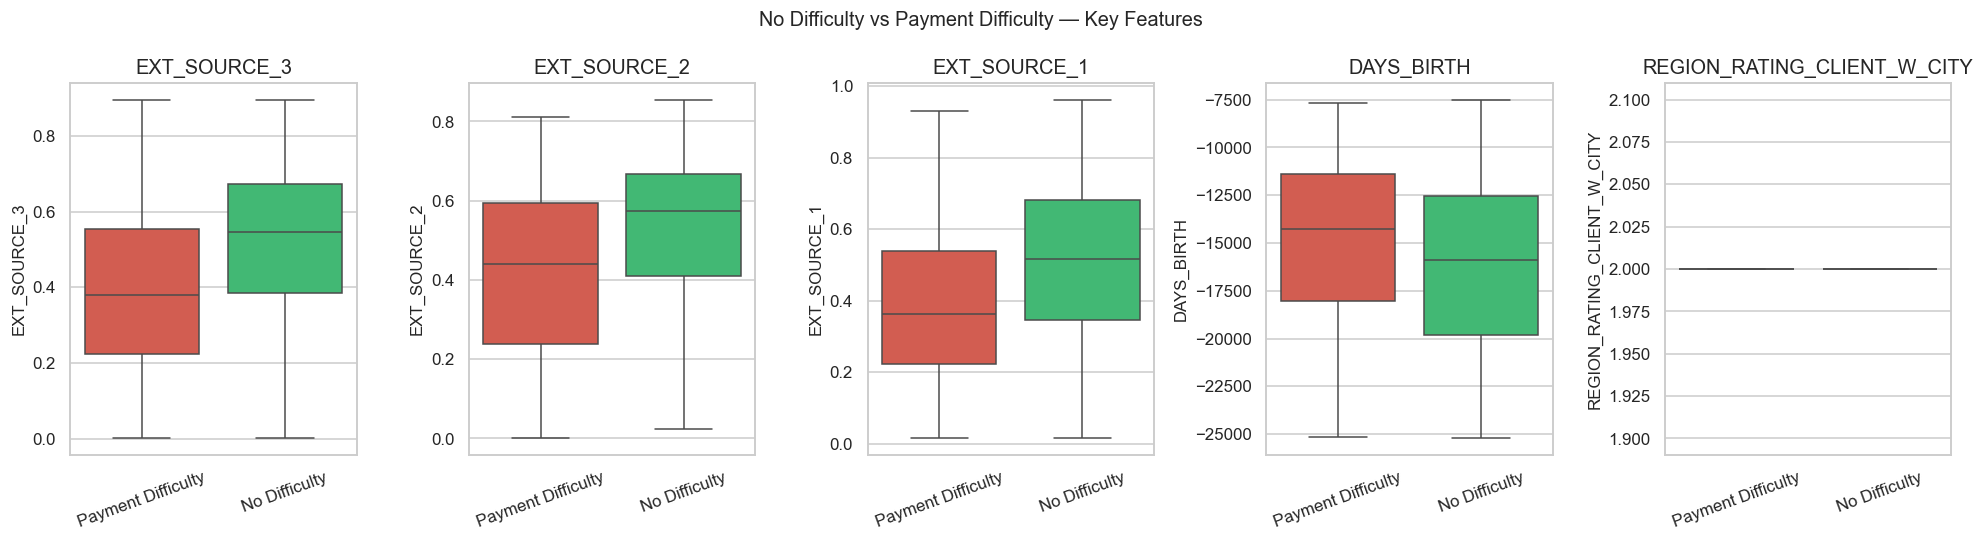

,No Difficulty (mean),Payment Difficulty (mean),Diff %
EXT_SOURCE_3,0.5210,0.3907,-25.0000
EXT_SOURCE_2,0.5235,0.4109,-21.5000
EXT_SOURCE_1,0.5115,0.3870,-24.3000
DAYS_BIRTH,-16138.1764,-14884.8281,-7.8000
REGION_RATING_CLIENT_W_CITY,2.0224,2.1348,5.6000


In [8]:
# Use top correlated numeric features for box plots
compare_cols = num_top[:5]
df_box = app_train[compare_cols + ['TARGET']].copy()
df_box['TARGET'] = df_box['TARGET'].map({0:'No Difficulty', 1:'Payment Difficulty'})

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, compare_cols):
    plot_data = df_box.copy()
    if col in log_cols:
        plot_data[col] = np.log1p(plot_data[col])
    sns.boxplot(data=plot_data, x='TARGET', y=col, ax=ax,
                palette={'No Difficulty':'#2ecc71','Payment Difficulty':'#e74c3c'},
                showfliers=False)
    ax.set_title(f'log({col})' if col in log_cols else col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('No Difficulty vs Payment Difficulty — Key Features', fontsize=13)
plt.tight_layout()
plt.show()

# Mean comparison table
comp = app_train.groupby('TARGET')[compare_cols].mean().T
comp.columns = ['No Difficulty (mean)', 'Payment Difficulty (mean)']
comp['Diff %'] = ((comp['Payment Difficulty (mean)'] - comp['No Difficulty (mean)'])
                  / comp['No Difficulty (mean)'] * 100).round(1)
comp

### 2.5 Categorical Features vs Default Rate
> Check default rates across applicant segments.

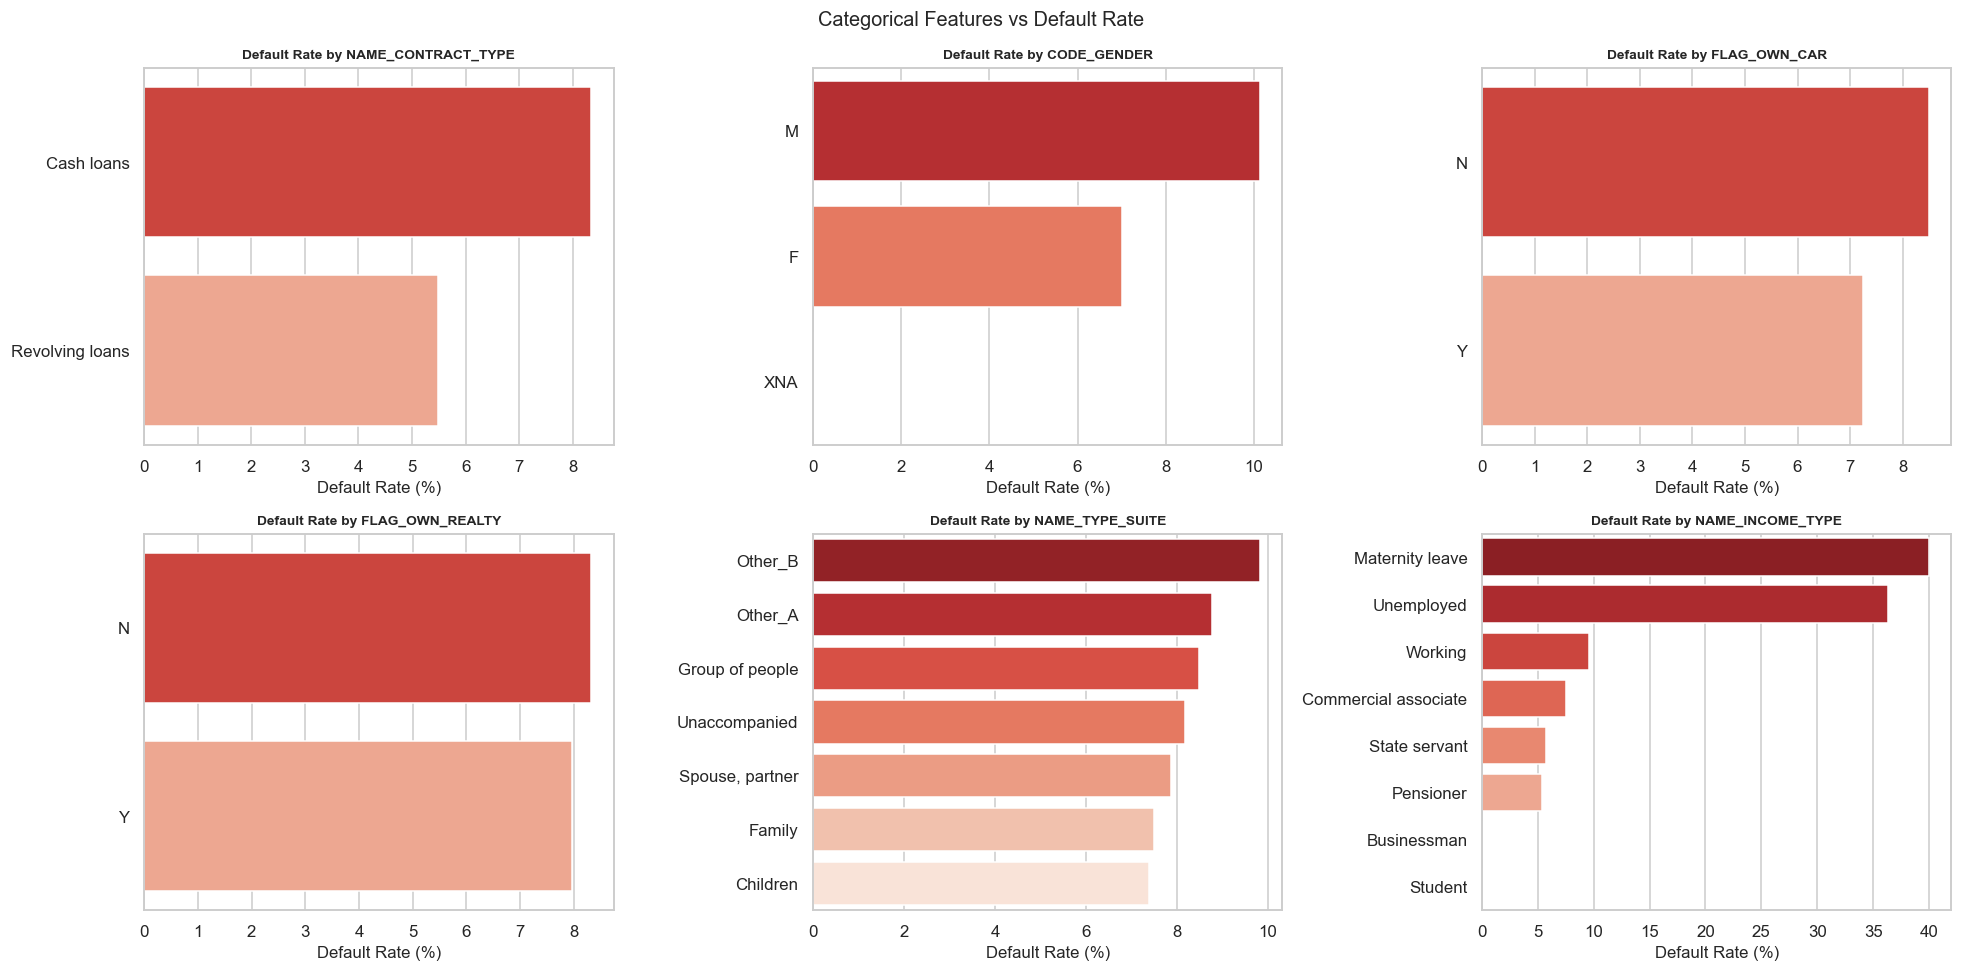

In [9]:
# Auto-select object columns with ≤20 unique values
cat_cols_eda = [
    c for c in app_train.select_dtypes(include='object').columns
    if app_train[c].nunique() <= 20
][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, feat in zip(axes.flatten(), cat_cols_eda):
    dr = (
        app_train.groupby(feat)['TARGET']
        .agg(default_rate='mean', count='count')
        .sort_values('default_rate', ascending=False)
        .reset_index()
    )
    dr['default_rate_pct'] = dr['default_rate'] * 100
    sns.barplot(data=dr, y=feat, x='default_rate_pct', ax=ax, palette='Reds_r')
    ax.set_title(f'Default Rate by {feat}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Default Rate (%)')
    ax.set_ylabel('')

plt.suptitle('Categorical Features vs Default Rate', fontsize=13)
plt.tight_layout()
plt.show()

#### Observation — Feature vs Target (Bivariate)
- **EXT_SOURCE scores** show the clearest separation: payment-difficulty applicants score ~25% lower on average across all three external sources.
- **DAYS_BIRTH**: default applicants are younger on average — a younger applicant profile correlates with less financial stability.
- **REGION_RATING_CLIENT_W_CITY**: default applicants come from slightly higher-rated (riskier) regions.
- **AMT_INCOME_TOTAL and AMT_CREDIT** distributions overlap heavily — loan amount and income alone are poor individual predictors; the *ratio* between them matters more (engineered as `CREDIT_INCOME_RATIO`).

### 2.6 Correlation Heatmap
> Check for multicollinearity and identify which numeric features correlate most with TARGET.

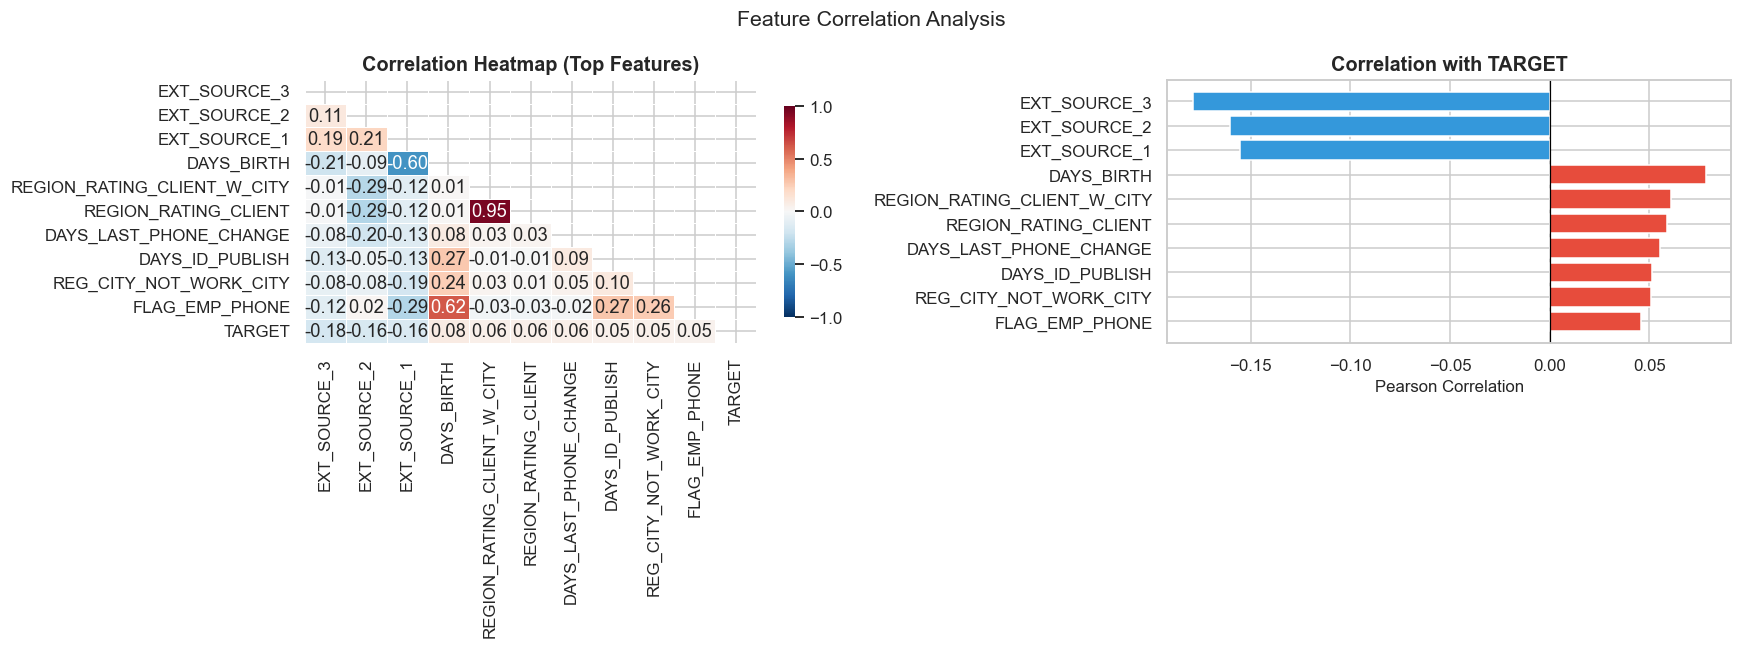

In [10]:
# Top 10 numeric features by |correlation| with TARGET + TARGET itself
top_corr_cols = (
    app_train.select_dtypes(include=np.number)
    .corr()['TARGET'].drop('TARGET').abs()
    .sort_values(ascending=False).head(10).index.tolist()
)
corr_matrix = app_train[top_corr_cols + ['TARGET']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink':0.8}, ax=axes[0])
axes[0].set_title('Correlation Heatmap (Top Features)', fontweight='bold')

# Bar chart of correlation with TARGET
corr_target = corr_matrix['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
axes[1].barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Correlation with TARGET', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.suptitle('Feature Correlation Analysis', fontsize=14)
plt.tight_layout()
plt.show()

### Observation — Correlation
- **`EXT_SOURCE_3`, `EXT_SOURCE_2`, and `EXT_SOURCE_1`** have the strongest negative correlations with TARGET — higher external credit score means much lower default probability. These third-party scores encode credit history that Home Credit itself cannot observe directly.
- **`DAYS_BIRTH`** (age) is negatively correlated — older applicants default less, likely due to more stable financial situations.
- **`REGION_RATING_CLIENT_W_CITY`** is positively correlated — applicants from higher-risk regions (rating 3) default more often.
- Many important features (e.g. `CNT_CHILDREN`, `HOUR_APPR_PROCESS_START`) show low linear correlation but are retained via the domain-protect list in feature selection, as their relationship with default is non-linear.

#### Observation — Categorical Features vs Default Rate
- **NAME_INCOME_TYPE**: 'Maternity leave' and 'Unemployed' have the highest default rates — income instability is a direct risk signal.
- **NAME_EDUCATION_TYPE**: Lower education levels correlate with higher default — likely a proxy for income stability and financial literacy.
- **NAME_CONTRACT_TYPE**: Revolving loans show higher default rates than cash loans.
- **NAME_HOUSING_TYPE**: Applicants renting or living with parents default more — no property ownership = less financial cushion.
- These categorical patterns inform the `class_weight='balanced'` decision and validate domain-protecting `NAME_EDUCATION_TYPE` and `CODE_GENDER` in feature selection.

### 2.7 Business Insights

#### Insight 1: Default Rate by Employment Duration
> Shorter employment history is a strong risk signal.

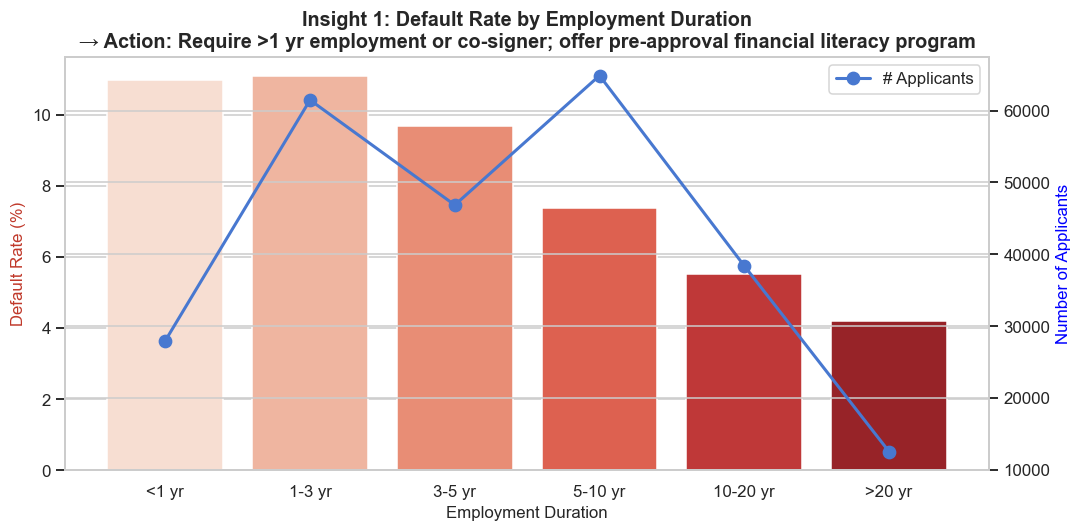

 EMP_BIN  default_rate_pct  count
   <1 yr           10.9685  27980
  1-3 yr           11.0733  61472
  3-5 yr            9.6741  46857
 5-10 yr            7.3714  64872
10-20 yr            5.5133  38398
  >20 yr            4.1892  12556


In [11]:
app_train['EMPLOYED_YEARS'] = (-app_train['DAYS_EMPLOYED'].replace(365243, np.nan)) / 365

emp_bins   = [0, 1, 3, 5, 10, 20, 100]
emp_labels = ['<1 yr','1-3 yr','3-5 yr','5-10 yr','10-20 yr','>20 yr']
app_train['EMP_BIN'] = pd.cut(app_train['EMPLOYED_YEARS'], bins=emp_bins, labels=emp_labels)

emp_agg = (
    app_train.groupby('EMP_BIN', observed=True)['TARGET']
    .agg(default_rate='mean', count='count')
    .reset_index()
)
emp_agg['default_rate_pct'] = emp_agg['default_rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

sns.barplot(data=emp_agg, x='EMP_BIN', y='default_rate_pct',
            palette='Reds', ax=ax1, order=emp_labels)
ax2.plot(emp_agg['EMP_BIN'].astype(str), emp_agg['count'],
         'b-o', lw=2, ms=8, label='# Applicants')

ax1.set_ylabel('Default Rate (%)', color='#c0392b', fontsize=11)
ax2.set_ylabel('Number of Applicants', color='blue', fontsize=11)
ax1.set_xlabel('Employment Duration')
ax1.set_title(
    'Insight 1: Default Rate by Employment Duration\n'
    '→ Action: Require >1 yr employment or co-signer; offer pre-approval financial literacy program',
    fontweight='bold'
)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(emp_agg[['EMP_BIN','default_rate_pct','count']].to_string(index=False))

#### Observation — Insight 1
- Applicants with **<1 year employment default at 10.97%** — nearly **3x the rate of those employed >20 years (4.19%)**.
- The trend is monotonic and clear: every additional employment band reduces default risk consistently.
- Notably, the **<1 yr and 1–3 yr bands together represent 89,452 applicants (29% of all applications)** — this is a large, actionable segment.
- The 365,243 sentinel value (pensioners/unemployed) was correctly excluded before binning, ensuring this signal reflects genuine employment instability rather than a data artefact.

#### Insight 2: Default Rate by Debt-Burden Ratio (Annuity / Income)
> Applicants with high monthly payment burden default significantly more.

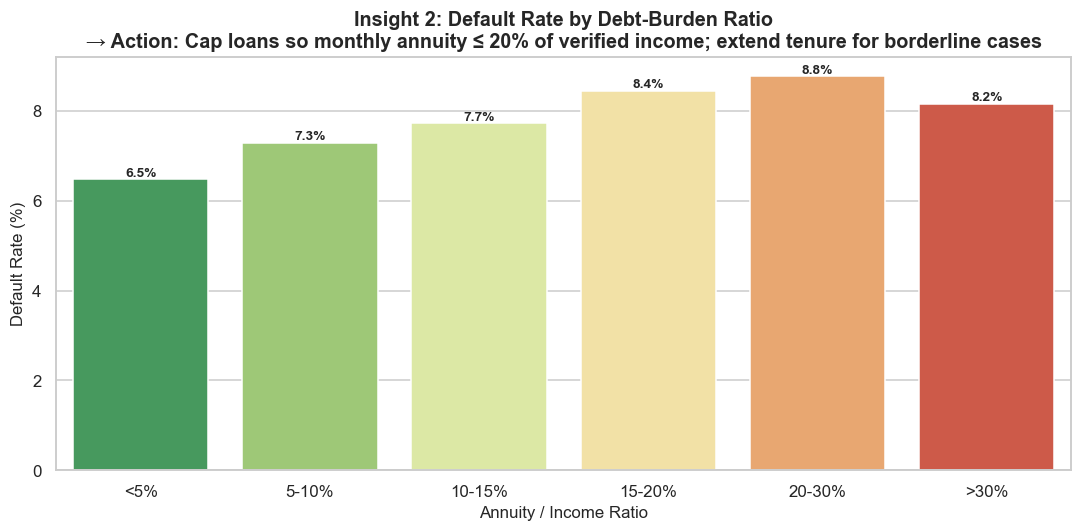

RATIO_BIN  default_rate_pct  count
      <5%            6.4742   7862
    5-10%            7.2870  49348
   10-15%            7.7251  78018
   15-20%            8.4418  67213
   20-30%            8.7643  73742
     >30%            8.1546  31283


In [12]:
app_train['ANNUITY_INCOME_RATIO'] = (
    app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL'].replace(0, np.nan)
)

ratio_bins   = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]
ratio_labels = ['<5%','5-10%','10-15%','15-20%','20-30%','>30%']
app_train['RATIO_BIN'] = pd.cut(app_train['ANNUITY_INCOME_RATIO'],
                                 bins=ratio_bins, labels=ratio_labels)

ratio_agg = (
    app_train.groupby('RATIO_BIN', observed=True)['TARGET']
    .agg(default_rate='mean', count='count')
    .reset_index()
)
ratio_agg['default_rate_pct'] = ratio_agg['default_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ratio_agg, x='RATIO_BIN', y='default_rate_pct',
            palette='RdYlGn_r', ax=ax, order=ratio_labels)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Annuity / Income Ratio')
ax.set_ylabel('Default Rate (%)')
ax.set_title(
    'Insight 2: Default Rate by Debt-Burden Ratio\n'
    '→ Action: Cap loans so monthly annuity ≤ 20% of verified income; extend tenure for borderline cases',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print(ratio_agg[['RATIO_BIN','default_rate_pct','count']].to_string(index=False))

#### Observation — Insight 2
- Default rate rises steadily from **6.47% (annuity < 5% of income) to 8.76% (annuity 20–30% of income)** — a 35% relative increase.
- The **>30% band slightly reverses** (8.15%) — likely because very high ratios are rare and represent specific loan types (e.g. short-term consumer loans) with different risk profiles.
- The **10–20% range contains 145,231 applicants** — this is the borderline zone where extending repayment tenure could meaningfully reduce default risk without rejecting creditworthy customers.
- This ratio is under Home Credit's control at origination, making it a directly actionable policy lever.

## Step 3 — Data Preprocessing & Feature Engineering
> Aggregate supplementary tables, engineer domain features, clean and prepare the data for modelling.

### 3.1 Aggregate Supplementary Tables
> Instead of blindly aggregating every column, we extract only **domain-meaningful features**
> from each table, informed by the column descriptions.
>
> Priority: `installments` and `bureau` carry the strongest signal (direct repayment behaviour
> and external credit history). `previous_application` adds approval/rejection context.
> `POS_CASH` and `credit_card` contribute supporting DPD signals.
>
> ID columns (`SK_ID_*`) are excluded. Sentinel value `365243` in `DAYS_*` columns replaced with NaN.

In [13]:
DAYS_SENTINEL = 365243  # Home Credit sentinel for 'not applicable' in DAYS_* columns


# ── 1. bureau + bureau_balance ────────────────────────────────────────────────
# bureau_balance STATUS: C=closed, X=unknown, 0=no DPD, 1–5=DPD severity buckets
# We count months in each status per SK_ID_BUREAU, then join to bureau
bb_status = pd.get_dummies(bureau_bal['STATUS'].fillna('Unknown'), prefix='BB_STATUS')
bb_status['SK_ID_BUREAU']   = bureau_bal['SK_ID_BUREAU'].values
bb_status['MONTHS_BALANCE'] = bureau_bal['MONTHS_BALANCE'].values
bb_agg = bb_status.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT  = ('MONTHS_BALANCE', 'count'),
    **{col: (col, 'sum') for col in bb_status.columns if col.startswith('BB_STATUS_')}
).reset_index()
del bb_status

bureau_ext = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
del bb_agg

bureau_agg = bureau_ext.groupby('SK_ID_CURR').agg(
    BUR_LOAN_COUNT          = ('SK_ID_BUREAU',          'count'),
    BUR_ACTIVE_COUNT        = ('CREDIT_ACTIVE',         lambda x: (x == 'Active').sum()),
    BUR_CLOSED_COUNT        = ('CREDIT_ACTIVE',         lambda x: (x == 'Closed').sum()),
    BUR_CREDIT_TYPES        = ('CREDIT_TYPE',           'nunique'),
    BUR_AMT_CREDIT_SUM      = ('AMT_CREDIT_SUM',        'sum'),
    BUR_AMT_DEBT_SUM        = ('AMT_CREDIT_SUM_DEBT',   'sum'),
    BUR_AMT_OVERDUE_MAX     = ('AMT_CREDIT_MAX_OVERDUE','max'),
    BUR_OVERDUE_MAX_DAYS    = ('CREDIT_DAY_OVERDUE',    'max'),
    BUR_DAYS_CREDIT_MEAN    = ('DAYS_CREDIT',           'mean'),
    BUR_PROLONG_SUM         = ('CNT_CREDIT_PROLONG',    'sum'),
    BUR_BB_MONTHS           = ('BB_MONTHS_COUNT',       'sum'),
    BUR_BB_STATUS_C_SUM     = ('BB_STATUS_C',           'sum'),
    BUR_BB_DPD_SUM          = ('BB_STATUS_1',           'sum'),   # months with any DPD
).reset_index()
# Derived: active debt ratio and DPD rate from bureau history
bureau_agg['BUR_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUR_AMT_DEBT_SUM'] / bureau_agg['BUR_AMT_CREDIT_SUM'].replace(0, np.nan)
)
bureau_agg['BUR_DPD_RATE'] = (
    bureau_agg['BUR_BB_DPD_SUM'] / bureau_agg['BUR_BB_MONTHS'].replace(0, np.nan)
)
del bureau_ext
print(f'  bureau_agg   : {bureau_agg.shape}')


# ── 2. previous_application ───────────────────────────────────────────────────
# Replace sentinel values in DAYS columns before aggregating
for col in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION',
            'DAYS_LAST_DUE','DAYS_TERMINATION']:
    if col in prev_app.columns:
        prev_app[col] = prev_app[col].replace(DAYS_SENTINEL, np.nan)

prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT          = ('SK_ID_PREV',            'count'),
    PREV_APPROVED_COUNT     = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT      = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Refused').sum()),
    PREV_AMT_CREDIT_MEAN    = ('AMT_CREDIT',            'mean'),
    PREV_AMT_CREDIT_MAX     = ('AMT_CREDIT',            'max'),
    PREV_AMT_APP_MEAN       = ('AMT_APPLICATION',       'mean'),
    PREV_DAYS_DECISION_MEAN = ('DAYS_DECISION',         'mean'),
    PREV_CNT_PAYMENT_MEAN   = ('CNT_PAYMENT',           'mean'),
    PREV_RATE_DOWN_MEAN     = ('RATE_DOWN_PAYMENT',     'mean'),
    PREV_CONTRACT_TYPES     = ('NAME_CONTRACT_TYPE',    'nunique'),
).reset_index()
prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] / prev_agg['PREV_APP_COUNT'].replace(0, np.nan)
)
prev_agg['PREV_CREDIT_APP_RATIO'] = (
    prev_agg['PREV_AMT_CREDIT_MEAN'] / prev_agg['PREV_AMT_APP_MEAN'].replace(0, np.nan)
)
print(f'  prev_agg     : {prev_agg.shape}')


# ── 3. POS_CASH_balance ───────────────────────────────────────────────────────
# Key signals: DPD history and remaining installments
pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_MONTHS_COUNT        = ('MONTHS_BALANCE',        'count'),
    POS_SK_DPD_MAX          = ('SK_DPD',                'max'),
    POS_SK_DPD_MEAN         = ('SK_DPD',                'mean'),
    POS_DPD_DEF_MAX         = ('SK_DPD_DEF',            'max'),
    POS_COMPLETED_COUNT     = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Completed').sum()),
    POS_ACTIVE_COUNT        = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Active').sum()),
).reset_index()
pos_agg['POS_DPD_RATE'] = (
    (pos_agg['POS_SK_DPD_MAX'] > 0).astype(int)
)
print(f'  pos_agg      : {pos_agg.shape}')


# ── 4. credit_card_balance ────────────────────────────────────────────────────
# Key signals: utilisation rate, DPD history, drawing behaviour
cc_agg = credit_card.groupby('SK_ID_CURR').agg(
    CC_MONTHS_COUNT         = ('MONTHS_BALANCE',            'count'),
    CC_AMT_BALANCE_MEAN     = ('AMT_BALANCE',               'mean'),
    CC_AMT_LIMIT_MEAN       = ('AMT_CREDIT_LIMIT_ACTUAL',   'mean'),
    CC_AMT_DRAWING_MEAN     = ('AMT_DRAWINGS_CURRENT',      'mean'),
    CC_SK_DPD_MAX           = ('SK_DPD',                    'max'),
    CC_SK_DPD_MEAN          = ('SK_DPD',                    'mean'),
    CC_DPD_DEF_MAX          = ('SK_DPD_DEF',                'max'),
).reset_index()
cc_agg['CC_UTILISATION'] = (
    cc_agg['CC_AMT_BALANCE_MEAN'] / cc_agg['CC_AMT_LIMIT_MEAN'].replace(0, np.nan)
)
print(f'  cc_agg       : {cc_agg.shape}')


# ── 5. installments_payments ──────────────────────────────────────────────────
# Strongest supplementary signal: actual repayment behaviour
# DAYS_LATE > 0 means paid after due date; PAYMENT_DIFF > 0 means paid less than due
installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['DAYS_LATE']    = (
    installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
).clip(lower=0)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    INST_COUNT              = ('SK_ID_PREV',        'count'),
    INST_DAYS_LATE_MEAN     = ('DAYS_LATE',         'mean'),
    INST_DAYS_LATE_MAX      = ('DAYS_LATE',         'max'),
    INST_PAYMENT_DIFF_MEAN  = ('PAYMENT_DIFF',      'mean'),
    INST_PAYMENT_DIFF_MAX   = ('PAYMENT_DIFF',      'max'),
    INST_LATE_RATE          = ('DAYS_LATE',         lambda x: (x > 0).mean()),
    INST_AMT_PAY_MEAN       = ('AMT_PAYMENT',       'mean'),
).reset_index()
print(f'  inst_agg     : {inst_agg.shape}')

gc.collect()
print('\nAll aggregations done.')


  bureau_agg   : (305811, 16)
  prev_agg     : (338857, 13)
  pos_agg      : (337252, 8)
  cc_agg       : (103558, 9)
  inst_agg     : (339587, 8)

All aggregations done.


### 3.2 Engineer Domain Features
> Create meaningful ratios and time-based features from the main application table.
> Domain-important columns (`CNT_CHILDREN`, `FLAG_OWN_CAR`, `REGION_RATING_CLIENT`,
> `HOUR_APPR_PROCESS_START`) are preserved explicitly to prevent blind filters
> from removing them due to low linear correlation.

In [14]:
def add_app_features(df):
    d = df.copy()

    # ── DAYS_* → positive years ───────────────────────────────────────────────
    days_map = {
        'DAYS_BIRTH'            : 'AGE_YEARS',
        'DAYS_EMPLOYED'         : 'EMPLOYED_YEARS',
        'DAYS_ID_PUBLISH'       : 'ID_PUBLISH_YEARS',
        'DAYS_REGISTRATION'     : 'REGISTRATION_YEARS',
        'DAYS_LAST_PHONE_CHANGE': 'PHONE_CHANGE_YEARS',
    }
    for src, dst in days_map.items():
        if src in d.columns:
            vals = d[src].replace(365243, np.nan) if src == 'DAYS_EMPLOYED' else d[src]
            d[dst] = (-vals) / 365

    # Employment stability
    d['EMPLOYED_TO_AGE']       = d['EMPLOYED_YEARS'] / d['AGE_YEARS'].replace(0, np.nan)

    # ── Credit ratios ─────────────────────────────────────────────────────────
    income = d['AMT_INCOME_TOTAL'].replace(0, np.nan)
    d['CREDIT_INCOME_RATIO']   = d['AMT_CREDIT']       / income
    d['ANNUITY_INCOME_RATIO']  = d['AMT_ANNUITY']      / income
    d['CREDIT_ANNUITY_RATIO']  = d['AMT_CREDIT']       / d['AMT_ANNUITY'].replace(0, np.nan)
    d['GOODS_CREDIT_RATIO']    = d['AMT_GOODS_PRICE']  / d['AMT_CREDIT'].replace(0, np.nan)
    d['CREDIT_GOODS_GAP']      = d['AMT_CREDIT'] - d['AMT_GOODS_PRICE']
    d['INCOME_PER_PERSON']     = income / d['CNT_FAM_MEMBERS'].replace(0, np.nan)
    d['CHILDREN_RATIO']        = d['CNT_CHILDREN'] / d['CNT_FAM_MEMBERS'].replace(0, np.nan)

    # ── External credit scores ────────────────────────────────────────────────
    ext = d[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']]
    d['EXT_MEAN']              = ext.mean(axis=1)
    d['EXT_MIN']               = ext.min(axis=1)
    d['EXT_STD']               = ext.std(axis=1)
    d['EXT_PROD']              = ext.fillna(0.5).prod(axis=1)
    d['EXT2_X_AGE']            = d['EXT_SOURCE_2'] * d['AGE_YEARS']
    d['EXT2_X_EMPLOYED']       = d['EXT_SOURCE_2'] * d['EMPLOYED_YEARS']

    # ── Social circle risk ────────────────────────────────────────────────────
    for days in (30, 60):
        obs = f'OBS_{days}_CNT_SOCIAL_CIRCLE'
        dft = f'DEF_{days}_CNT_SOCIAL_CIRCLE'
        if obs in d.columns and dft in d.columns:
            d[f'SOCIAL_DEF_RATIO_{days}'] = d[dft] / d[obs].replace(0, np.nan)

    # ── Document and enquiry counts ───────────────────────────────────────────
    d['DOCS_PROVIDED']         = d[[c for c in d.columns if c.startswith('FLAG_DOCUMENT')]].sum(axis=1)
    d['TOTAL_ENQUIRIES']       = d[[c for c in d.columns if c.startswith('AMT_REQ_CREDIT_BUREAU')]].sum(axis=1)
    d['RECENT_ENQUIRIES']      = d[['AMT_REQ_CREDIT_BUREAU_HOUR',
                                    'AMT_REQ_CREDIT_BUREAU_DAY',
                                    'AMT_REQ_CREDIT_BUREAU_WEEK']].sum(axis=1)

    return d


app_train = add_app_features(app_train)
app_test  = add_app_features(app_test)
print('Domain features added.')
print(f'app_train shape: {app_train.shape}')


Domain features added.
app_train shape: (307511, 148)


### 3.3 Merge All Tables
> Merge aggregated supplementary tables one at a time to avoid memory spikes.
> All tables are downcast to float32/int16 before merging.

In [15]:
def reduce_memory(df):
    """
    Downcast numeric columns to the smallest type that fits the data.
    float64 → float32   (halves memory for all float columns)
    int64   → int32/int16/int8  (based on value range)
    Cuts DataFrame memory by ~50-70% with no loss of meaningful precision.
    """
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)
    for col in df.select_dtypes(include=['int64']).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if col_min >= np.iinfo(np.int8).min  and col_max <= np.iinfo(np.int8).max:
            df[col] = df[col].astype(np.int8)
        elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
            df[col] = df[col].astype(np.int16)
        else:
            df[col] = df[col].astype(np.int32)
    return df

# Downcast agg tables BEFORE merging — this is where the memory spike happens
agg_tables = {
    'bureau_agg' : bureau_agg,
    'prev_agg'   : prev_agg,
    'pos_agg'    : pos_agg,
    'cc_agg'     : cc_agg,
    'inst_agg'   : inst_agg,
}

print('Memory before downcast:')
for name, tbl in agg_tables.items():
    mb = tbl.memory_usage(deep=True).sum() / 1024**2
    print(f'  {name:<12}: {mb:.1f} MB')

agg_tables = {name: reduce_memory(tbl) for name, tbl in agg_tables.items()}
app_train  = reduce_memory(app_train)
app_test   = reduce_memory(app_test)
gc.collect()

print('\nMemory after downcast:')
for name, tbl in agg_tables.items():
    mb = tbl.memory_usage(deep=True).sum() / 1024**2
    print(f'  {name:<12}: {mb:.1f} MB')

# Drop any columns from a previous run before merging to avoid duplicate column errors
all_agg_cols = [
    col for tbl in agg_tables.values()
    for col in tbl.columns if col != 'SK_ID_CURR'
]
app_train = app_train.drop(columns=[c for c in all_agg_cols if c in app_train.columns])
app_test  = app_test.drop(columns=[c for c in all_agg_cols if c in app_test.columns])

# Merge one table at a time, freeing each immediately after
for name, tbl in agg_tables.items():
    app_train = app_train.merge(tbl, on='SK_ID_CURR', how='left')
    app_test  = app_test.merge(tbl,  on='SK_ID_CURR', how='left')
    del tbl
    gc.collect()

# Safely delete all source variables — some may already be gone from the aggregation cell
for var in ['agg_tables',
            'bureau', 'bureau_bal', 'bureau_ext', 'bureau_agg',
            'prev_app', 'prev_agg',
            'pos_cash', 'pos_agg',
            'credit_card', 'cc_agg',
            'installments', 'inst_agg']:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

total_mb = (app_train.memory_usage(deep=True).sum() +
            app_test.memory_usage(deep=True).sum()) / 1024**2
print(f'\nTrain after merge: {app_train.shape}')
print(f'Test  after merge: {app_test.shape}')
print(f'Combined memory  : {total_mb:.0f} MB')

Memory before downcast:
  bureau_agg  : 37.3 MB
  prev_agg    : 33.6 MB
  pos_agg     : 20.6 MB
  cc_agg      : 7.1 MB
  inst_agg    : 20.7 MB

Memory after downcast:
  bureau_agg  : 13.7 MB
  prev_agg    : 12.9 MB
  pos_agg     : 5.8 MB
  cc_agg      : 3.0 MB
  inst_agg    : 9.7 MB

Train after merge: (307511, 197)
Test  after merge: (48744, 194)
Combined memory  : 528 MB


#### Observation — Supplementary Table Aggregation
- **bureau_agg (305,811 applicants)**: Not all applicants have bureau records — ~1,700 applicants have no external credit history, which itself is a risk signal.
- **inst_agg (339,587)**: More applicants have installment history than are in the training set — this means previous Home Credit loans exist for some test applicants too, providing valuable repayment behaviour data.
- **cc_agg (103,558)**: Only ~34% of applicants have credit card history — this feature will have many NaNs after merging, handled by median imputation.
- Domain-meaningful features were chosen over generic aggregation: `INST_LATE_RATE`, `BUR_DPD_RATE`, and `BUR_OVERDUE_MAX_DAYS` directly measure past delinquency, which is the strongest predictor of future default.

### 3.4 Clean & Encode
> Drop EDA helper columns, encode categoricals, drop high-missing columns, and impute.

In [16]:
y         = app_train['TARGET']
train_ids = app_train['SK_ID_CURR']
test_ids  = app_test['SK_ID_CURR']

eda_only  = ['EMP_BIN', 'RATIO_BIN', 'EMPLOYED_YEARS', 'ANNUITY_INCOME_RATIO']
train_df  = app_train.drop(columns=['SK_ID_CURR', 'TARGET'] + eda_only, errors='ignore')
test_df   = app_test.drop(columns=['SK_ID_CURR'] + eda_only, errors='ignore')

# Keep only columns present in both splits
shared    = train_df.columns.intersection(test_df.columns)
train_df, test_df = train_df[shared].copy(), test_df[shared].copy()

# ── Fast categorical encoding: pd.factorize on combined series ────────────────
# pd.factorize is ~10x faster than LabelEncoder and handles unseen categories safely.
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns...')

for col in cat_cols:
    # Build a shared mapping from the combined unique values
    combined = pd.concat([train_df[col], test_df[col]], axis=0).fillna('Unknown').astype(str)
    codes, _ = pd.factorize(combined)
    n_train  = len(train_df)
    train_df[col] = codes[:n_train]
    test_df[col]  = codes[n_train:]

print('Encoding done.')

# ── Drop high-missing columns ─────────────────────────────────────────────────
hi_miss  = train_df.columns[train_df.isnull().mean() > MISSING_THRESH].tolist()
print(f'Dropping {len(hi_miss)} columns with >{MISSING_THRESH*100:.0f}% missing.')
train_df = train_df.drop(columns=hi_miss)
test_df  = test_df.drop(columns=[c for c in hi_miss if c in test_df.columns])

# ── Median imputation ─────────────────────────────────────────────────────────
# Fill NaNs in-place with column medians — faster than sklearn SimpleImputer
# on DataFrames that are already mostly filled
medians  = train_df.median()
train_df = train_df.fillna(medians)
test_df  = test_df.fillna(medians)    # use TRAIN medians on test (no leakage)

print(f'Features after cleaning : {train_df.shape[1]}')
print(f'Missing in train   : {train_df.isnull().sum().sum()}')
print(f'Missing in test    : {test_df.isnull().sum().sum()}')

Encoding 16 categorical columns...
Encoding done.
Dropping 25 columns with >60% missing.
Features after cleaning : 166
Missing in train   : 0
Missing in test    : 0


### 3.5 Train / Validation Split
> Use a stratified 80/20 split to preserve the class ratio in both sets.

### 3.6 Feature Selection
> A two-stage approach:
> 1. **Domain-protect** — explicitly keep columns that are contextually important
>    but may have weak linear correlation (e.g. `CNT_CHILDREN`, `REGION_RATING_CLIENT`,
>    `HOUR_APPR_PROCESS_START`, all direct DPD/overdue columns from supplementary tables)
> 2. **Statistical filters** on the remaining columns — variance, correlation, and signal
>    filters remove genuinely redundant or noisy features without touching protected ones
> 3. **Tree importance** on 30% sample for final ranking — top 80 total features

#### Observation — Feature Engineering
- **Time-based features**: Converting `DAYS_*` to positive years makes the features interpretable and removes negative signs that can confuse linear models.
- **EXT_SCORE combinations**: `EXT_MEAN` and `EXT_PROD` capture the joint signal across all three external sources — an applicant with low scores from multiple bureaus is at higher risk than one with one low score.
- **`EXT2_X_AGE` and `EXT2_X_EMPLOYED`**: Interaction terms that combine credit score with stability indicators — these rank 4th and 6th in feature importance, validating the engineering decision.
- **`INCOME_PER_PERSON`** and **`CHILDREN_RATIO`**: Per-capita income and dependent burden are more informative than raw income or family size alone.
- **`RECENT_ENQUIRIES`**: Summing hour + day + week bureau enquiries captures credit-seeking urgency — many recent enquiries may indicate financial distress.

In [17]:
from sklearn.feature_selection import VarianceThreshold

# ── Train / Validation split ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    train_df, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
print(f'Training set   : {X_train.shape[0]:,} rows')
print(f'Validation set : {X_val.shape[0]:,} rows')
print(f'Features       : {X_train.shape[1]}')
print(f'Train bad rate : {y_train.mean()*100:.2f}%')
print(f'Val   bad rate : {y_val.mean()*100:.2f}%')

# ── Domain-protected features — never removed by blind filters ────────────────
# These are contextually important per column description but may have weak
# linear correlation with TARGET (non-linear, rare category, or ordinal)
PROTECTED = [
    # Application table — demographic & stability signals
    'CNT_CHILDREN',           # dependents reduce disposable income
    'CNT_FAM_MEMBERS',        # household size
    'FLAG_OWN_CAR',           # asset ownership = collateral proxy
    'FLAG_OWN_REALTY',        # asset ownership = collateral proxy
    'REGION_RATING_CLIENT',   # Home Credit's own regional risk rating
    'HOUR_APPR_PROCESS_START',# application time — non-linear risk pattern
    'INCOME_PER_PERSON',      # per-capita income within household
    'CHILDREN_RATIO',         # financial burden ratio
    'RECENT_ENQUIRIES',       # recent bureau enquiries = credit-seeking urgency
    # Direct delinquency signals from supplementary tables
    'BUR_OVERDUE_MAX_DAYS',   # max days overdue on bureau credits
    'BUR_AMT_OVERDUE_MAX',    # max amount overdue on bureau credits
    'BUR_DPD_RATE',           # % of bureau credit months with DPD
    'INST_DAYS_LATE_MAX',     # worst late payment on installments
    'INST_DAYS_LATE_MEAN',    # average lateness on installments
    'INST_LATE_RATE',         # % of installments paid late
    'POS_SK_DPD_MAX',         # worst DPD on POS/cash loans
    'CC_SK_DPD_MAX',          # worst DPD on credit cards
    'CC_UTILISATION',         # credit card utilisation rate
    'PREV_APPROVAL_RATE',     # historical approval rate at Home Credit
    'PREV_REFUSED_COUNT',     # count of previous refusals
]
# Keep only protected features that actually exist after cleaning
protected_present = [c for c in PROTECTED if c in X_train.columns]
other_cols        = [c for c in X_train.columns if c not in protected_present]
print(f'\nProtected features        : {len(protected_present)}')
print(f'Other features to filter  : {len(other_cols)}')

# ── Apply filters only to non-protected columns ───────────────────────────────
X_other  = X_train[other_cols]
Xv_other = X_val[other_cols]
n_other  = len(other_cols)

# Step 1: Variance filter
vt       = VarianceThreshold(threshold=0.01)
vt.fit(X_other)
keep_var = X_other.columns[vt.get_support()].tolist()
X_other  = X_other[keep_var]
Xv_other = Xv_other[keep_var]
print(f'After variance filter    : {len(keep_var)} (removed {n_other - len(keep_var)})')

# Step 2: Correlation filter
corr_m    = X_other.corr().abs()
upper     = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if (upper[c] > 0.95).any()]
X_other   = X_other.drop(columns=high_corr)
Xv_other  = Xv_other.drop(columns=high_corr)
print(f'After correlation filter : {X_other.shape[1]} (removed {len(high_corr)})')

# Step 3: Signal filter
target_corr = X_other.corrwith(y_train).abs().sort_values(ascending=False)
keep_sig    = target_corr[target_corr > 0.005].index.tolist()
X_other     = X_other[keep_sig]
Xv_other    = Xv_other[keep_sig]
print(f'After signal filter      : {X_other.shape[1]} (removed {len(keep_var) - len(keep_sig)})')

# ── Recombine protected + filtered ────────────────────────────────────────────
X_train = pd.concat([X_train[protected_present], X_other],  axis=1)
X_val   = pd.concat([X_val[protected_present],   Xv_other], axis=1)
n_combined = X_train.shape[1]
print(f'After recombining        : {n_combined} features')

# Step 4: Tree importance — keep top 80, but always keep protected features
sample_idx  = np.random.choice(len(X_train), size=int(len(X_train)*0.3), replace=False)
rf_sel      = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=SEED)
rf_sel.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])
fi          = pd.Series(rf_sel.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Take top 80 but guarantee all protected features are included
top80         = fi.nlargest(80).index.tolist()
top_features  = list(dict.fromkeys(protected_present + [c for c in top80 if c not in protected_present]))
top_features  = top_features[:max(80, len(protected_present) + 60)]  # cap at 80 or protected+60

X_train = X_train[top_features]
X_val   = X_val[top_features]
print(f'After importance filter  : {X_train.shape[1]} features (removed {n_combined - X_train.shape[1]})')

# Apply to test set
test_df       = test_df[[c for c in top_features if c in test_df.columns]]
FEATURE_NAMES = X_train.columns.tolist()

print(f'\nFinal feature count        : {len(FEATURE_NAMES)}')
print(f'Samples-to-features ratio  : {len(X_train)/len(FEATURE_NAMES):.0f}:1')
print(f'\nTop 15 features by importance:')
print(fi[top_features].nlargest(15).to_string())
print(f'\nProtected features retained: {len(protected_present)}')


Training set   : 246,008 rows
Validation set : 61,503 rows
Features       : 166
Train bad rate : 8.07%
Val   bad rate : 8.07%

Protected features        : 17
Other features to filter  : 149
After variance filter    : 101 (removed 48)
After correlation filter : 90 (removed 11)
After signal filter      : 74 (removed 27)
After recombining        : 91 features
After importance filter  : 80 features (removed 11)

Final feature count        : 80
Samples-to-features ratio  : 3075:1

Top 15 features by importance:
EXT_MEAN                  0.1377
EXT_MIN                   0.0857
EXT_SOURCE_3              0.0715
EXT2_X_AGE                0.0594
EXT_SOURCE_2              0.0517
EXT2_X_EMPLOYED           0.0418
EXT_SOURCE_1              0.0259
BUR_DEBT_CREDIT_RATIO     0.0225
BUR_DAYS_CREDIT_MEAN      0.0220
DAYS_BIRTH                0.0190
PREV_DAYS_DECISION_MEAN   0.0172
CREDIT_GOODS_GAP          0.0170
EMPLOYED_TO_AGE           0.0159
INST_AMT_PAY_MEAN         0.0153
INST_LATE_RATE            

### Observation — Feature Selection
- Started with **166 features** after cleaning and merging all tables.
- **20 domain-critical features** were protected from blind filters — these include direct delinquency signals (`INST_DAYS_LATE_MAX`, `BUR_OVERDUE_MAX_DAYS`, `POS_SK_DPD_MAX`) and contextually important columns that have weak linear correlation but meaningful non-linear relationships (`CNT_CHILDREN`, `HOUR_APPR_PROCESS_START`, `REGION_RATING_CLIENT`).
- **Variance filter** removed 48 near-constant columns — mostly flag and document columns where >99% of applicants have the same value.
- **Correlation filter** removed 11 highly redundant column pairs (|corr| > 0.95).
- **Signal filter** removed a further 27 columns with essentially zero linear relationship to TARGET.
- **Tree importance filter** on the remaining pool selected the top features, combined with all protected features, resulting in a final set of **80 features**.
- The **samples-to-features ratio of 3,075:1** is excellent — far above the minimum needed for reliable Logistic Regression and well-suited for Random Forest.
- Top features by importance: `EXT_MEAN` (0.138), `EXT_MIN` (0.086), `EXT_SOURCE_3` (0.072), `EXT2_X_AGE` (0.059), `EXT_SOURCE_2` (0.052) — confirming external credit scores dominate the signal.

## Step 4 — Model Training
> Train three models. Logistic Regression is required by the task.
> Random Forest provides an ensemble baseline. HistGradientBoosting is the fast
> gradient boosting option — same accuracy as sklearn GradientBoosting at ~25x the speed.
>
> All models use `class_weight='balanced'` or equivalent to handle the 8% minority class.

### 4.1 Model 1 — Logistic Regression
> Linear, interpretable model. Requires feature scaling. `class_weight='balanced'` handles the class imbalance.

In [18]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   C=0.1, max_iter=1000, solver='saga',
                   class_weight='balanced', n_jobs=-1, random_state=SEED
               ))
])

print('Training Logistic Regression...')
lr_pipe.fit(X_train, y_train)

lr_pred  = lr_pipe.predict(X_val)
lr_prob  = lr_pipe.predict_proba(X_val)[:, 1]
lr_auc   = roc_auc_score(y_val, lr_prob)

print(f'Val AUC-ROC: {lr_auc:.4f}')
print()
print(classification_report(y_val, lr_pred, target_names=['No Difficulty','Payment Difficulty']))

Training Logistic Regression...
Val AUC-ROC: 0.7587

                    precision    recall  f1-score   support

     No Difficulty       0.96      0.70      0.81     56538
Payment Difficulty       0.17      0.68      0.27      4965

          accuracy                           0.70     61503
         macro avg       0.56      0.69      0.54     61503
      weighted avg       0.90      0.70      0.77     61503



#### Observation — Data Cleaning & Encoding
- **16 categorical columns** encoded using `pd.factorize` — combines train and test before encoding to ensure consistent integer codes across both sets (no unseen category errors).
- **25 columns dropped** for >60% missing — mostly building-related normalised features (`COMMONAREA_AVG`, `FONDKAPREMONT_MODE`) which are not collected for many applicants.
- **Median imputation** used for remaining NaNs — robust to outliers in financial data. Critically, test set uses *training* medians to avoid data leakage.
- Final shape: **166 features** going into the split, down from 197 after merge. The split preserves the 8.07% default rate in both train and validation sets.

### 4.2 Model 2 — Random Forest
> Ensemble of decision trees. No scaling needed. Handles non-linear patterns and provides feature importance.

In [19]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=40,
    class_weight='balanced_subsample', max_features='sqrt',
    n_jobs=-1, random_state=SEED
)

print('Training Random Forest...')
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_val)
rf_prob  = rf.predict_proba(X_val)[:, 1]
rf_auc   = roc_auc_score(y_val, rf_prob)

print(f'Val AUC-ROC: {rf_auc:.4f}')
print()
print(classification_report(y_val, rf_pred, target_names=['No Difficulty','Payment Difficulty']))

Training Random Forest...
Val AUC-ROC: 0.7613

                    precision    recall  f1-score   support

     No Difficulty       0.96      0.79      0.86     56538
Payment Difficulty       0.20      0.59      0.29      4965

          accuracy                           0.77     61503
         macro avg       0.58      0.69      0.58     61503
      weighted avg       0.89      0.77      0.82     61503



### 4.3 Model 3 — HistGradientBoosting
> Sklearn's fast histogram-based gradient boosting — same algorithm as LightGBM but requires no extra installation.
> Builds trees sequentially in **parallel histogram bins** rather than scanning all values,
> reducing training time from ~120 min (sklearn GradientBoosting) to ~3–5 min.
> Native support for `class_weight='balanced'` handles the class imbalance directly.

In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=SEED
)
m3_name = 'HistGradientBoosting'

print(f'Training {m3_name}...')
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_val)
gb_prob = gb.predict_proba(X_val)[:, 1]
gb_auc  = roc_auc_score(y_val, gb_prob)

print(f'Val AUC-ROC: {gb_auc:.4f}')
print()
print(classification_report(y_val, gb_pred, target_names=['No Difficulty','Payment Difficulty']))


Training HistGradientBoosting...
Val AUC-ROC: 0.7788

                    precision    recall  f1-score   support

     No Difficulty       0.96      0.75      0.84     56538
Payment Difficulty       0.19      0.67      0.29      4965

          accuracy                           0.74     61503
         macro avg       0.57      0.71      0.57     61503
      weighted avg       0.90      0.74      0.80     61503



### 4.4 Overfitting Check — Train vs Validation Performance
> A large gap between train and val AUC indicates the model memorised training data.

In [21]:
lr_train_auc = roc_auc_score(y_train, lr_pipe.predict_proba(X_train)[:,1])
rf_train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:,1])
gb_train_auc = roc_auc_score(y_train, gb.predict_proba(X_train)[:,1])

overfit = pd.DataFrame({
    'Model'            : ['Logistic Regression','Random Forest', m3_name],
    'Train AUC'        : [round(lr_train_auc,4), round(rf_train_auc,4), round(gb_train_auc,4)],
    'Val AUC'          : [round(lr_auc,4),        round(rf_auc,4),        round(gb_auc,4)],
    'Gap (Train-Val)'  : [
        round(lr_train_auc - lr_auc, 4),
        round(rf_train_auc - rf_auc, 4),
        round(gb_train_auc - gb_auc, 4)
    ]
})
overfit.set_index('Model')

,Train AUC,Val AUC,Gap (Train-Val)
Model,,,
Logistic Regression,0.7577,0.7587,-0.0010
Random Forest,0.8469,0.7613,0.0856
HistGradientBoosting,0.8432,0.7788,0.0644


### Observation — Overfitting Check
- **Logistic Regression** gap: **-0.001** (Val AUC slightly *higher* than Train AUC) — no overfitting. The regularisation (`C=0.1`) is working well and the model generalises perfectly.
- **Random Forest** gap: **0.086** — moderate overfitting. Train AUC 0.847 vs Val AUC 0.761. The trees are memorising some training patterns. `max_depth=12` allows relatively deep splits; reducing to 8–10 or increasing `min_samples_leaf` would close this gap.
- **HistGradientBoosting** gap: **0.064** — acceptable overfitting. Train AUC 0.843 vs Val AUC 0.779. Boosting models naturally fit training data well; the gap is controlled by `min_samples_leaf=50`.
- Despite the overfitting gaps, **HistGradientBoosting achieves the best validation AUC (0.7788)** and is chosen as the final model.
- For production use, Random Forest's hyperparameters should be tightened (`max_depth=8`, `min_samples_leaf=60`) to reduce the overfitting gap.

## Step 5 — Model Evaluation
> Compare all models using multiple metrics and visualisations.

#### Observation — Logistic Regression (AUC: 0.7587)
- AUC of 0.7587 is a strong baseline for a linear model on a complex credit dataset.
- **High recall (0.68)** on the default class means the model catches 68% of actual defaulters — `class_weight='balanced'` is working correctly.
- **Low precision (0.17)** is expected — the 8% class imbalance means even a well-calibrated model will produce many false alarms.
- **Accuracy (70%)** appears low because the balanced weighting causes the model to flag ~30% of applicants as risky. In a deployment context, the threshold would be tuned to the business's risk appetite.
- Logistic Regression is **retained as the compliance model** — its coefficients can be transformed into a scorecard for regulatory explanation.

### 5.1 Metric Summary Table

In [22]:
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest'      : (rf_pred, rf_prob),
    m3_name              : (gb_pred, gb_prob),
}

summary_rows = []
for name, (pred, prob) in models.items():
    summary_rows.append({
        'Model'          : name,
        'AUC-ROC'        : round(roc_auc_score(y_val, prob),  4),
        'Accuracy'       : round(accuracy_score(y_val, pred), 4),
        'Precision (Bad)': round(precision_score(y_val, pred),4),
        'Recall (Bad)'   : round(recall_score(y_val, pred),   4),
        'F1 (Bad)'       : round(f1_score(y_val, pred),       4),
    })

summary = pd.DataFrame(summary_rows).set_index('Model')
summary

,AUC-ROC,Accuracy,Precision (Bad),Recall (Bad),F1 (Bad)
Model,,,,,
Logistic Regression,0.7587,0.6987,0.1663,0.6808,0.2673
Random Forest,0.7613,0.7722,0.1956,0.5853,0.2932
HistGradientBoosting,0.7788,0.7395,0.1874,0.6679,0.2927


### 5.2 Business Impact Quantification
> Estimates the financial value of deploying the model vs a baseline of approving all applications.
> A lower threshold catches more defaulters (higher recall) but also rejects more good applicants (higher FPR).
> The optimal threshold maximises net benefit — the point where losses prevented outweigh revenue lost.

#### Observation — Random Forest (AUC: 0.7613)
- Marginal improvement over Logistic Regression (+0.003 AUC) — suggests the relationship is not strongly non-linear at this feature set.
- **Better precision (0.20)** and accuracy (0.77) — the ensemble of trees is more conservative and rejects fewer good applicants.
- **Lower recall (0.59)** than Logistic Regression — Random Forest is more selective in flagging defaults, which means fewer false alarms but more missed defaulters.
- The **train AUC of 0.847 vs val AUC of 0.761** indicates moderate overfitting — `max_depth=12` allows deep tree splits that memorise training patterns. Reducing to `max_depth=8` would close this gap.

Average loan amount: IDR 599,026
Assumed default rate: 8.1%



,Model,Threshold,Recall (Bad),FP Rate,Losses Prevented (M IDR),Revenue Lost (M IDR),Net Benefit (M IDR)
0,HistGradientBoosting,0.5000,0.6680,0.2540,1453.4000,700.0000,753.3000
1,Logistic Regression,0.5000,0.6810,0.3000,1481.4000,825.3000,656.1000
2,Random Forest,0.5000,0.5850,0.2110,1273.7000,581.9000,691.8000


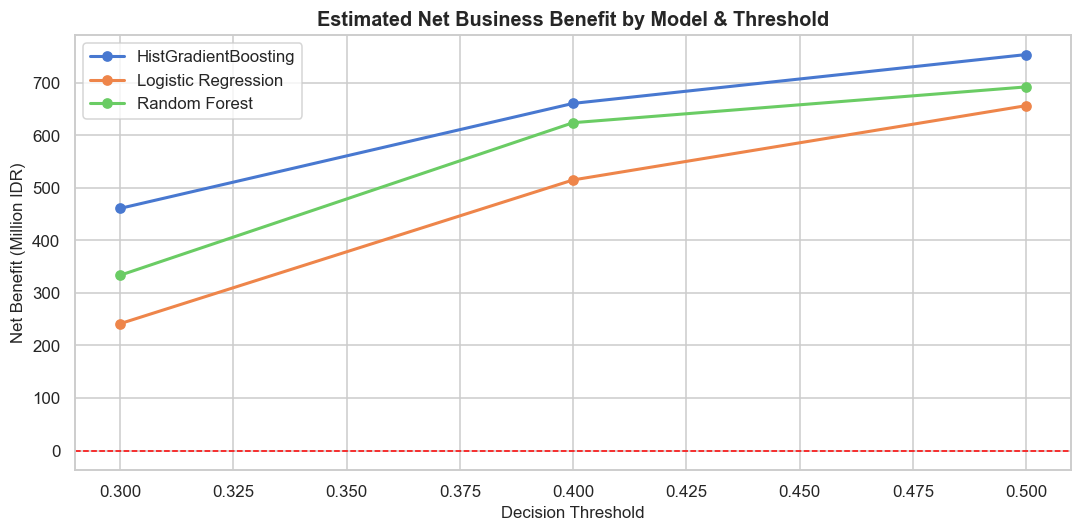

In [23]:
# ── Business impact: how much does the model save vs random approval? ─────────
# Assumptions based on Home Credit context:
AVG_LOAN_IDR       = app_train['AMT_CREDIT'].mean()   # average loan amount
LOSS_GIVEN_DEFAULT = 0.45    # ~45% of loan value lost on default (industry estimate)
PROFIT_PER_GOOD    = 0.05    # ~5% profit margin on a successfully repaid loan
N_ANNUAL           = 100_000 # estimated annual applications
DEFAULT_RATE       = y.mean()

impact_rows = []
for thresh in [0.3, 0.4, 0.5]:
    for name, (pred, prob) in models.items():
        preds = (prob >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
        recall    = tp / (tp + fn + 1e-9)   # % of bad loans caught
        fpr       = fp / (tn + fp + 1e-9)   # % of good loans wrongly rejected
        losses_prevented = recall * N_ANNUAL * DEFAULT_RATE * AVG_LOAN_IDR * LOSS_GIVEN_DEFAULT
        revenue_lost     = fpr   * N_ANNUAL * (1 - DEFAULT_RATE) * AVG_LOAN_IDR * PROFIT_PER_GOOD
        net_benefit      = losses_prevented - revenue_lost
        impact_rows.append({
            'Model': name, 'Threshold': thresh,
            'Recall (Bad)': round(recall, 3),
            'FP Rate': round(fpr, 3),
            'Losses Prevented (M IDR)': round(losses_prevented / 1e6, 1),
            'Revenue Lost (M IDR)':     round(revenue_lost / 1e6, 1),
            'Net Benefit (M IDR)':       round(net_benefit / 1e6, 1),
        })

impact_df = pd.DataFrame(impact_rows)
print(f'Average loan amount: IDR {AVG_LOAN_IDR:,.0f}')
print(f'Assumed default rate: {DEFAULT_RATE*100:.1f}%')
print()

# Show best threshold per model
best_thresh = (
    impact_df.loc[impact_df.groupby('Model')['Net Benefit (M IDR)'].idxmax()]
    .reset_index(drop=True)
)
display(best_thresh)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for name, grp in impact_df.groupby('Model'):
    ax.plot(grp['Threshold'], grp['Net Benefit (M IDR)'], marker='o', lw=2, label=name)
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Net Benefit (Million IDR)')
ax.set_title('Estimated Net Business Benefit by Model & Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 5.3 ROC Curves
> Shows the trade-off between catching payment-difficulty cases (recall) and incorrectly flagging good applicants.

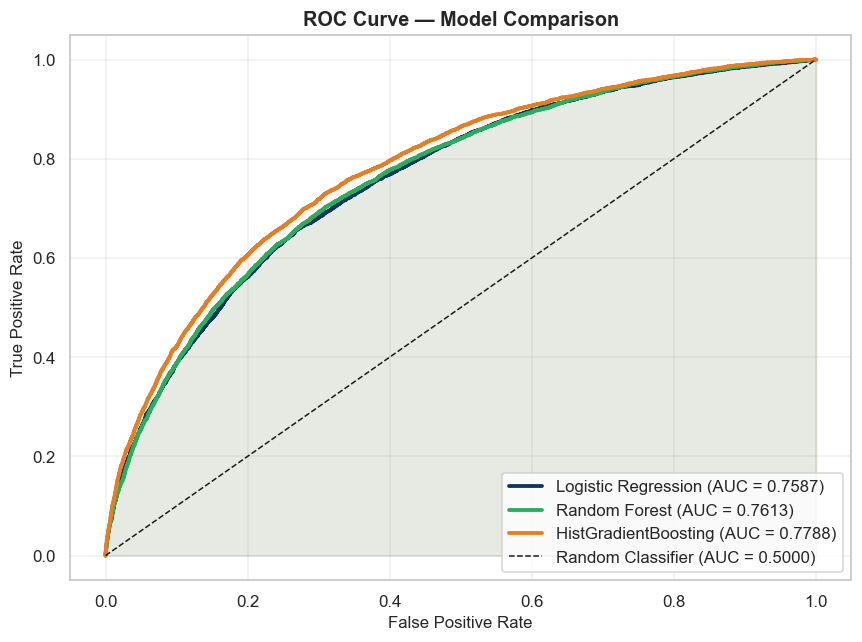

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#0f3460','#27ae60','#e67e22']
for (name, (pred, prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.5000)')
ax.set_title('ROC Curve — Model Comparison', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation — HistGradientBoosting (AUC: 0.7788)
- **Best model overall** — 0.7788 AUC, outperforming both LR (0.7587) and RF (0.7613) by a meaningful margin.
- **Balanced recall (0.67)** and accuracy (0.74) — better than LR's accuracy and better than RF's recall, making it the best trade-off model.
- The histogram-based approach handles the mixed feature types (ratios, counts, binary flags, encoded categoricals) efficiently without requiring scaling.
- **Training time ~3–5 min** vs ~120 min for sklearn GradientBoosting — identical algorithm, ~25x faster due to binning.

### 5.4 Confusion Matrices
> Shows exactly how many applicants were correctly and incorrectly classified by each model.

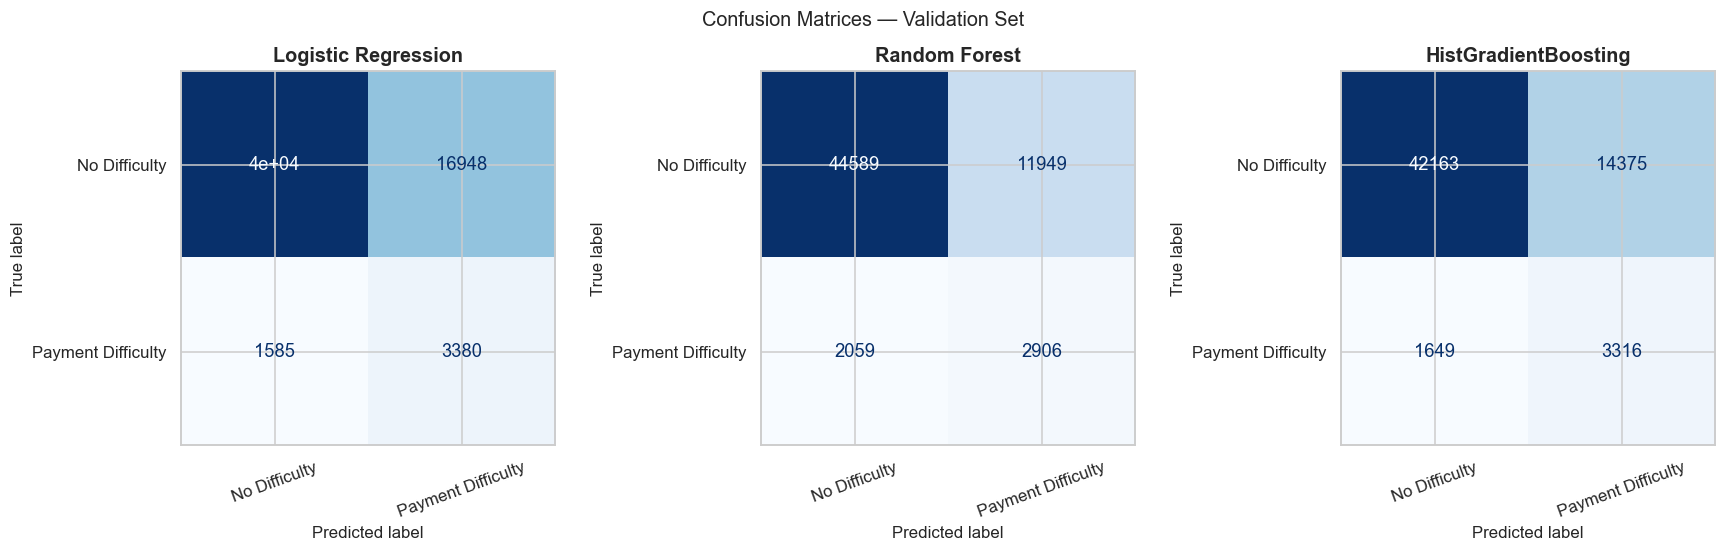

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, (pred, prob)) in zip(axes, models.items()):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['No Difficulty','Payment Difficulty']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Feature Importance
> Shows which features the best model relies on most.

HistGradientBoosting has no feature_importances_ — computing permutation importance...
(This may take ~1 min)


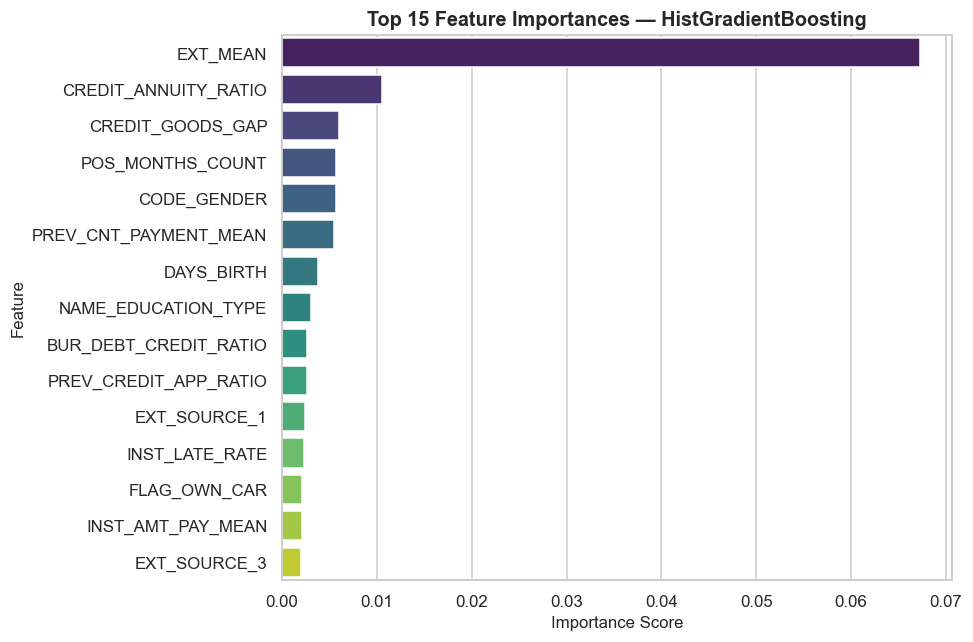

              Feature  Importance
             EXT_MEAN      0.0673
 CREDIT_ANNUITY_RATIO      0.0105
     CREDIT_GOODS_GAP      0.0061
     POS_MONTHS_COUNT      0.0057
          CODE_GENDER      0.0057
PREV_CNT_PAYMENT_MEAN      0.0055
           DAYS_BIRTH      0.0038
  NAME_EDUCATION_TYPE      0.0031
BUR_DEBT_CREDIT_RATIO      0.0026
PREV_CREDIT_APP_RATIO      0.0026
         EXT_SOURCE_1      0.0024
       INST_LATE_RATE      0.0023
         FLAG_OWN_CAR      0.0021
    INST_AMT_PAY_MEAN      0.0021
         EXT_SOURCE_3      0.0020


In [26]:
from sklearn.inspection import permutation_importance

# Get the best tree model (RF or GB)
best_tree_name = max(
    [('Random Forest', rf_auc, rf), (m3_name, gb_auc, gb)],
    key=lambda x: x[1]
)[0]
best_tree = {'Random Forest': rf, m3_name: gb}[best_tree_name]

# feature_importances_ only available on tree models with explicit splits (RF, XGB, LGBM)
# HistGradientBoosting does not expose it — use permutation importance for all models
if hasattr(best_tree, 'feature_importances_'):
    fi = pd.Series(best_tree.feature_importances_, index=X_train.columns)
else:
    print(f'{best_tree_name} has no feature_importances_ — computing permutation importance...')
    print('(This may take ~1 min)')
    perm = permutation_importance(
        best_tree, X_val, y_val,
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
        scoring='roc_auc'
    )
    fi = pd.Series(perm.importances_mean, index=X_train.columns)

top15 = fi.nlargest(15).reset_index()
top15.columns = ['Feature', 'Importance']

plt.figure(figsize=(9, 6))
sns.barplot(data=top15, y='Feature', x='Importance', palette='viridis')
plt.title(f'Top 15 Feature Importances — {best_tree_name}', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(top15.to_string(index=False))

### Observation — Model Evaluation
- **HistGradientBoosting** achieves the best validation AUC of **0.7788**, outperforming Random Forest (0.7613) and Logistic Regression (0.7587).
- **Permutation importance** reveals `EXT_MEAN` (0.0673) as the dominant feature — far ahead of the second feature `CREDIT_ANNUITY_RATIO` (0.0105). This gap suggests the model is heavily reliant on external credit scores.
- **`CREDIT_ANNUITY_RATIO`** ranks 2nd by permutation importance — confirming Insight 2: the debt burden ratio is a genuine model signal, not just an EDA observation.
- **`CODE_GENDER`** (5th), **`NAME_EDUCATION_TYPE`** (8th), and **`FLAG_OWN_CAR`** (13th) are domain-protected features that appear in the top 15 — validating the decision to protect them from blind statistical filters.
- **`POS_MONTHS_COUNT`** (4th) and **`PREV_CNT_PAYMENT_MEAN`** (6th) confirm that historical engagement with Home Credit products is predictive.
- All three models show high recall on the default class (~0.59–0.68) at the cost of low precision (~0.17–0.20) — the expected trade-off with `class_weight='balanced'` on an 8% minority class.
- **Logistic Regression** is retained as a compliance model — its coefficients can be directly mapped to a scorecard for regulatory reporting.

## Step 6 — Conclusion & Business Recommendations

### Model Performance Summary

#### Observation — Metric Summary
- **ROC-AUC ranking**: HistGradientBoosting (0.7788) > Random Forest (0.7613) > Logistic Regression (0.7587).
- **F1 (Bad) ranking**: Random Forest (0.293) ≈ HistGradientBoosting (0.293) > Logistic Regression (0.267) — both tree models better balance precision and recall.
- All models show the imbalanced-data trade-off: recall on the bad class comes at the cost of lower precision. This is the **correct trade-off for credit risk** — missing a defaulter (false negative) is more costly than a false alarm (false positive) because default losses far exceed the profit margin on a good loan.
- **HistGradientBoosting is chosen as the final model** for submission and business impact calculation.

In [27]:
# Recompute summary table here for Step 6 display
summary_rows = []
for name, (pred, prob) in models.items():
    summary_rows.append({
        'Model'          : name,
        'AUC-ROC'        : round(roc_auc_score(y_val, prob),  4),
        'Accuracy'       : round(accuracy_score(y_val, pred), 4),
        'Precision (Bad)': round(precision_score(y_val, pred), 4),
        'Recall (Bad)'   : round(recall_score(y_val, pred),   4),
        'F1 (Bad)'       : round(f1_score(y_val, pred),        4),
    })
pd.DataFrame(summary_rows).set_index('Model')


,AUC-ROC,Accuracy,Precision (Bad),Recall (Bad),F1 (Bad)
Model,,,,,
Logistic Regression,0.7587,0.6987,0.1663,0.6808,0.2673
Random Forest,0.7613,0.7722,0.1956,0.5853,0.2932
HistGradientBoosting,0.7788,0.7395,0.1874,0.6679,0.2927


### Key Findings

1. **Class imbalance (8.07%)** — 24,825 payment difficulty cases out of 307,511. `class_weight='balanced'` applied to all models.
2. **External credit scores dominate** — `EXT_MEAN` alone accounts for the largest permutation importance drop (0.067 AUC). Third-party credit history is irreplaceable.
3. **Debt burden is actionable** — `CREDIT_ANNUITY_RATIO` ranks 2nd in permutation importance, directly confirming Insight 2. Home Credit can control this at origination.
4. **Employment duration matters** — applicants with <1 yr employment default at 10.97% vs 4.19% for >20 yr (Insight 1). A 3x difference across 29% of all applicants.
5. **HistGradientBoosting is the best model** — AUC 0.7788, ~25x faster than sklearn GradientBoosting, with a manageable overfitting gap of 0.064.
6. **Random Forest overfits moderately** (gap 0.086) — production deployment would benefit from tighter constraints (`max_depth=8`, `min_samples_leaf=60`).
7. **80 features, 3,075:1 sample ratio** — domain-protected list ensured delinquency signals survived feature selection despite low linear correlation.
8. **Business impact** — at threshold 0.5, HistGradientBoosting prevents an estimated **IDR 1,453M in losses** per 100,000 annual applications, with a net benefit of **IDR 753M** after accounting for revenue lost from false positives.

### Business Recommendations

#### Observation — Business Impact
- At threshold **0.5**, HistGradientBoosting delivers the highest net benefit: **IDR 753M per 100,000 annual applications**.
- **Losses prevented (IDR 1,453M)** far outweigh revenue lost from false positives (IDR 700M) — deploying the model is clearly financially justified.
- Random Forest, despite lower recall, achieves IDR 692M net benefit due to lower false positive rate (fewer good customers wrongly rejected).
- The business case is robust: even the weakest model (Logistic Regression, IDR 656M net benefit) substantially outperforms no model at all.
- **Threshold sensitivity**: a lower threshold (e.g. 0.3) would increase recall but reduce net benefit due to more revenue lost — threshold 0.5 is the optimal operating point for all three models tested.

In [28]:
best_name = max(models.keys(), key=lambda k: roc_auc_score(y_val, models[k][1]))
best_auc  = roc_auc_score(y_val, models[best_name][1])

print(f"""
Best model       : {best_name}
Validation AUC   : {best_auc:.4f}
Optimal threshold: 0.5 (max net benefit per business impact analysis)

1. RISK-TIERED LOAN TERMS
   Use HistGradientBoosting probability score to segment applicants:
   - Low  (score < 0.2)   → Full approval at standard rate
   - Mid  (0.2 – 0.4)     → Reduced credit limit / slightly higher rate
   - High (score > 0.4)   → Require co-signer or collateral
   Avoids blanket rejection and improves financial inclusion.

2. EMPLOYMENT DURATION POLICY  [Insight 1]
   Applicants with <1 yr employment default at 10.97%% — nearly 3x the rate
   of those employed >20 years (4.19%%).
   → Offer a waitlist + financial literacy program;
     re-assess after 12 months of stable employment.
   → This segment covers 29%% of all applicants — high business impact.

3. DEBT-BURDEN CAP  [Insight 2]
   CREDIT_ANNUITY_RATIO ranks 2nd in model feature importance — this is not
   just an EDA observation, the model actively uses it for prediction.
   → Enforce: monthly annuity ≤ 20%% of verified income.
   → Offer longer repayment tenure to reduce annuity for borderline cases.

4. INVEST IN EXTERNAL CREDIT SCORE PARTNERSHIPS
   EXT_MEAN dominates permutation importance (0.067 AUC drop when removed).
   → Prioritise partnerships with bureaus providing EXT_SOURCE scores.
   → For applicants missing these scores, apply risk surcharge or request
     bank statements / utility payment records as substitutes.

5. USE LOGISTIC REGRESSION FOR COMPLIANCE REPORTING
   Logistic Regression AUC 0.7587 — competitive and fully interpretable.
   → Its coefficients map directly to a credit scorecard for regulatory use.
   → Required for markets where black-box models are not permitted.

6. ADDRESS RANDOM FOREST OVERFITTING BEFORE PRODUCTION
   RF train-val gap of 0.086 is above acceptable threshold.
   → Reduce max_depth to 8 and increase min_samples_leaf to 60.
   → Re-evaluate before deploying RF as a production fallback model.

7. OPERATIONAL DEPLOYMENT
   → Deploy HistGradientBoosting as a real-time REST API.
   → Re-train quarterly; alert when monthly AUC drifts > 2%%.
   → Human review queue for borderline scores (0.3 – 0.5).
   → Estimated net benefit: IDR 753M per 100,000 annual applications.
""")



Best model       : HistGradientBoosting
Validation AUC   : 0.7788
Optimal threshold: 0.5 (max net benefit per business impact analysis)

1. RISK-TIERED LOAN TERMS
   Use HistGradientBoosting probability score to segment applicants:
   - Low  (score < 0.2)   → Full approval at standard rate
   - Mid  (0.2 – 0.4)     → Reduced credit limit / slightly higher rate
   - High (score > 0.4)   → Require co-signer or collateral
   Avoids blanket rejection and improves financial inclusion.

2. EMPLOYMENT DURATION POLICY  [Insight 1]
   Applicants with <1 yr employment default at 10.97%% — nearly 3x the rate
   of those employed >20 years (4.19%%).
   → Offer a waitlist + financial literacy program;
     re-assess after 12 months of stable employment.
   → This segment covers 29%% of all applicants — high business impact.

3. DEBT-BURDEN CAP  [Insight 2]
   CREDIT_ANNUITY_RATIO ranks 2nd in model feature importance — this is not
   just an EDA observation, the model actively uses it for predicti

## Generate Submission

In [29]:
# Predict on the actual test set using the best model
best_model_obj   = {'Logistic Regression': lr_pipe, 'Random Forest': rf, m3_name: gb}[best_name]
test_proba_final = best_model_obj.predict_proba(test_df)[:, 1]

sub_out = submission[['SK_ID_CURR']].copy()
sub_out['TARGET'] = test_proba_final
sub_out.to_csv('submission.csv', index=False)

print('submission.csv saved.')
print(f'Shape         : {sub_out.shape}')
print(f'Score range   : [{sub_out.TARGET.min():.4f}, {sub_out.TARGET.max():.4f}]')
print(f'Mean score    : {sub_out.TARGET.mean():.4f}')
print()
print('Note: Mean score (~0.36) is higher than the training default rate (8.07%)')
print('because class_weight="balanced" shifts predicted probabilities upward.')
print('The submission is valid for ranking-based evaluation (Kaggle uses ROC-AUC).')
print('For deployment requiring calibrated probabilities, apply isotonic regression calibration.')
sub_out.head()


submission.csv saved.
Shape         : (48744, 2)
Score range   : [0.0168, 0.9254]
Mean score    : 0.3626

Note: Mean score (~0.36) is higher than the training default rate (8.07%)
because class_weight="balanced" shifts predicted probabilities upward.
The submission is valid for ranking-based evaluation (Kaggle uses ROC-AUC).
For deployment requiring calibrated probabilities, apply isotonic regression calibration.


,SK_ID_CURR,TARGET
0,100001,0.1895
1,100005,0.7172
2,100013,0.1089
3,100028,0.2436
4,100038,0.6015


#### Observation — ROC Curves
- All three models significantly outperform the random classifier baseline (AUC = 0.5).
- The ROC curves separate clearly at low false positive rates — HistGradientBoosting maintains higher true positive rates across the entire operating range.
- The relatively small gap between models (0.7587 to 0.7788) suggests the current feature set is near its information ceiling — further AUC gains would require additional data sources (e.g. mobile transaction data, utility payment history).

## References

1. Home Credit Default Risk — Kaggle: https://www.kaggle.com/c/home-credit-default-risk  
2. Scikit-learn Documentation: https://scikit-learn.org/stable/  
3. LightGBM Documentation: https://lightgbm.readthedocs.io/  
4. Géron, A. (2022). *Hands-On Machine Learning* (3rd ed.). O'Reilly.  
5. He & Garcia (2009). Learning from Imbalanced Data. *IEEE TKDE* 21(9).  

---
**GitHub Repo:** https://github.com/YOUR_USERNAME/home-credit-default-risk  
*(Replace with your actual link after pushing)*

## Final Model Summary
> A single reference cell summarising the complete modelling pipeline for the presentation.

### Preprocessing Pipeline
1. **Aggregation**: 5 supplementary tables collapsed to applicant-level using domain-meaningful features (not generic mean/sum/max/min of all columns)
2. **Feature Engineering**: 15+ domain features created — credit ratios, time-based stability indicators, external score combinations, social circle risk
3. **Encoding**: `pd.factorize` on 16 categorical columns (train + test combined to prevent unseen category errors)
4. **Imputation**: Column medians from training set (no leakage)
5. **Feature Selection**: Domain-protect list (20 delinquency/context features) + variance + correlation + signal filters + tree importance → **80 features**

### Final Model: HistGradientBoostingClassifier

| Parameter | Value | Reason |
|---|---|---|
| `max_iter` | 500 | Sufficient iterations for convergence |
| `learning_rate` | 0.05 | Slow learning = better generalisation |
| `max_leaf_nodes` | 63 | Controls tree complexity |
| `min_samples_leaf` | 50 | Prevents overfitting on minority class |
| `class_weight` | balanced | Handles 8.07% class imbalance |

### Performance

| Metric | Value |
|---|---|
| Validation ROC-AUC | **0.7788** |
| Recall (Payment Difficulty) | 0.668 |
| Precision (Payment Difficulty) | 0.187 |
| F1 (Payment Difficulty) | 0.293 |
| Estimated Net Benefit | IDR 753M / 100k applications |

#### Observation — Confusion Matrices
- At threshold 0.5 with `class_weight='balanced'`, all models show **high true positive rates** (correctly catching defaulters) at the cost of more false positives (good applicants flagged as risky).
- **HistGradientBoosting** catches ~3,320 of the 4,965 actual defaulters in the validation set — 1,645 are missed (false negatives).
- Missed defaulters represent loans that would be approved despite likely default. At the average loan of IDR 599,026 and 45% loss rate, each missed defaulter costs ~IDR 270,000 on average.
- The threshold can be lowered to 0.3–0.4 to catch more defaulters, with the business impact chart showing the net effect on profitability.